# Dem4Cli v2 development

1. New population data gridded - done > integrate into S2S
2. new masks for countries ? - coarsening to lower res - doing 
3. new cohort size data - done - check formatting / integrate for S2S
4. lookup table - add UNWPP life expectancy name column - done > do again but with original country mask column  
5. wrapper > done, check df_countries and mising objs are they necessary > adapt fxns cause not regionmask regions anymore


## Notes
- load_country_metadata() only v1 
- load_country_stats() only v1 and not very useful
- get_gridscale_demographics() and population_demographics_gridscale_global() only v1
- 197 countries included in all data sources and with SSP cohort size projections (218 included in all 3 but without cohort size projs)
    - Could get cohort sizes from UNWPP2024! Might lose less countries
    
To do 
- round da lat/lons in functions so they match up for multiplication etc. 


In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
import regionmask 
from shapely.geometry import box

warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 80)
%matplotlib inline 

sys.path.append('..')

from population_demographics_v2 import * 

In [2]:
flags

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

## 1. load new cohort size data



### a) see old data

In [6]:
flags['version'] = 1
dir_cohortsizes = os.path.join(script_dir, 'data/cohort-sizes/WCDE/')
ssp=2

df_cohort_sizes, ages, years = load_cohort_sizes(dir_cohortsizes)


In [7]:
df_cohort_sizes

,2_1950,2_1955,2_1960,2_1965,2_1970,2_1975,2_1980,2_1985,2_1990,2_1995,...,102_2055,102_2060,102_2065,102_2070,102_2075,102_2080,102_2085,102_2090,102_2095,102_2100
Area,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1291.6,1355.1,1539.5,1762.1,2025.6,2326.7,2484.4,2276.9,2377.9,3325.5,...,0.2,0.2,0.3,0.4,0.5,0.7,0.9,1.1,1.6,2.4
Albania,180.8,222.5,272.9,309.7,312.3,324.8,335.2,355.5,388.5,334.4,...,3.2,5.5,8.0,9.7,11.8,14.7,19.1,20.3,24.7,35.4
Algeria,1403.1,1830.6,2081.8,2398.0,2692.6,3086.2,3528.0,3893.8,3994.2,3734.3,...,15.7,23.0,35.4,52.8,78.8,123.7,179.8,235.8,281.4,297.1
Angola,739.2,1023.5,1095.3,1196.5,1298.7,1515.1,1810.3,2122.6,2438.5,2799.6,...,0.4,0.5,0.6,0.8,1.1,1.5,2.1,3.0,4.2,6.1
Antigua and Barbuda,6.6,8.4,8.9,9.2,9.9,9.3,7.3,7.2,7.4,6.8,...,0.0,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.3,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Western Sahara,2.4,3.3,5.4,8.7,13.2,13.3,23.0,29.2,31.8,34.6,...,0.0,0.0,0.1,0.1,0.2,0.3,0.4,0.5,0.7,0.9
World,338387.2,405612.1,432642.8,480601.0,523700.8,543302.0,548178.6,592792.3,644867.3,623061.1,...,5799.9,7789.0,10822.7,14499.7,18443.9,22134.8,28115.2,36321.0,42244.2,48218.6
Yemen,770.2,777.9,860.3,978.0,1173.4,1348.4,1709.7,2115.3,2603.1,3082.0,...,0.3,0.4,0.5,0.7,1.1,2.1,3.4,5.2,7.8,10.2


In [8]:
filepath = dir_cohortsizes+f'wicdf_ssp{ssp}.csv'
df_raw = pd.read_csv(filepath, header=7) # population is in 000's

# total national population through time (rows = countries with names from WCDE, check they match, columns = years)
df_pop_national = df_raw[(df_raw['Sex'] == 'Both') & (df_raw['Age'] == 'All')][['Area', 'Year', 'Population']].pivot(index="Area", columns="Year", values="Population")


In [9]:
df_raw # you want it to look like this!

,Area,Year,Age,Sex,ISOCode,Population
0,Afghanistan,1950,All,Both,4,7752.1
1,Afghanistan,1955,All,Both,4,8270.5
2,Afghanistan,1960,All,Both,4,8992.4
3,Afghanistan,1965,All,Both,4,9935.0
4,Afghanistan,1970,All,Both,4,11122.4
...,...,...,...,...,...,...
413287,Zimbabwe,2080,100+,Female,716,1.2
413288,Zimbabwe,2085,100+,Female,716,1.8
413289,Zimbabwe,2090,100+,Female,716,2.6
413290,Zimbabwe,2095,100+,Female,716,3.5


### b) new data

In [12]:
flags['version'] = 2
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [13]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/WCDE/'

In [14]:
filepath_cohortsizes=dir_cohortsizes+'/ssp_basic_drivers_release_3.2.beta_full.xlsx'

In [13]:
pd.read_excel(filepath_cohortsizes, sheet_name=1)

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
0,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 100+,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 15-19,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 20-24,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 25-29,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 30-34,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406882,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,167.817493,202.230159,242.446718,289.227372,344.150188,408.863839,484.958158,574.577244,679.527459,801.530437
406883,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2017/yr,NaN,NaN,NaN,NaN,NaN,...,142.607000,171.850000,206.025000,245.778000,292.450000,347.442000,412.105000,488.261000,577.445000,681.120000
406884,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2010/yr,NaN,NaN,NaN,NaN,NaN,...,7173.363687,8652.728869,10446.998134,12612.926499,15222.120997,18366.588436,22153.943502,26753.568238,32317.872273,39014.010438
406885,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,8073.332338,9738.298355,11757.676253,14195.341521,17131.884994,20670.856635,24933.372446,30110.065103,36372.465515,43908.699720


In [14]:

df = pd.read_excel(filepath_cohortsizes, sheet_name=1)

# 1. Exclude rows where 'region' contains (R<number>)
df = df[~df['Region'].str.contains(r"\(R\d+\)", regex=True, na=False)]

# 2. Keep only:
#    - Exactly "Population"
#    - Or "Population|Male|Age <age>"
#    - Or "Population|Female|Age <age>"
population_pattern = (
    #r"^Population$"  # exactly 'Population'
    r"^Population\|(Male|Female)\|Age\s(\d{1,2}(-\d{1,2})?|100\+)$" # age range
)

df = df[df['Variable'].str.contains(population_pattern, regex=True, na=False)]

In [16]:
df

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
38,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 0-4,million,0.630666,0.633850,0.713825,0.820112,0.949960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 10-14,million,0.405776,0.443287,0.511051,0.525418,0.608655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 100+,million,0.000000,0.000000,0.000000,0.000000,0.000001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 15-19,million,0.353874,0.386877,0.422271,0.493369,0.508750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 20-24,million,0.304909,0.332729,0.363826,0.402941,0.472583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399088,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 75-79,million,NaN,NaN,NaN,NaN,NaN,...,0.143250,0.204322,0.211735,0.242217,0.319896,0.395627,0.438217,0.529094,0.565268,0.594757
399095,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 80-84,million,NaN,NaN,NaN,NaN,NaN,...,0.070287,0.106202,0.155388,0.165164,0.193778,0.263518,0.334017,0.378790,0.467772,0.510505
399102,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 85-89,million,NaN,NaN,NaN,NaN,NaN,...,0.026024,0.042097,0.065886,0.099905,0.110098,0.133990,0.190208,0.250217,0.294268,0.376550
399109,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 90-94,million,NaN,NaN,NaN,NaN,NaN,...,0.007523,0.011178,0.018921,0.031030,0.049368,0.057166,0.073223,0.110432,0.153345,0.190379


In [17]:
# Extract sex and age from Variable
df['sex'] = df['Variable'].str.extract(r"^Population\|(Male|Female)", expand=False)
df['age'] = df['Variable'].str.extract(r"Age\s([\d\+]+(?:-\d+)?)", expand=False)


In [18]:
# Melt year columns to long format
year_cols = [c for c in df.columns if re.match(r"^\d{4}$", str(c))]
df_long = df.melt(
    id_vars=['Region', 'sex', 'age','Scenario'],
    value_vars=year_cols,
    var_name='time',
    value_name='population'
)
df_long['time'] = df_long['time'].astype(int)
df_long['Scenario'] = df_long['Scenario'].replace({'Historical Reference': 'historical'})



In [19]:
df_long

,Region,sex,age,Scenario,time,population
0,Afghanistan,Female,0-4,historical,1950,0.630666
1,Afghanistan,Female,10-14,historical,1950,0.405776
2,Afghanistan,Female,100+,historical,1950,0.000000
3,Afghanistan,Female,15-19,historical,1950,0.353874
4,Afghanistan,Female,20-24,historical,1950,0.304909
...,...,...,...,...,...,...
1623589,Zimbabwe,Male,75-79,SSP5,2100,0.594757
1623590,Zimbabwe,Male,80-84,SSP5,2100,0.510505
1623591,Zimbabwe,Male,85-89,SSP5,2100,0.376550
1623592,Zimbabwe,Male,90-94,SSP5,2100,0.190379


In [20]:
df_long.set_index(['Region', 'time', 'age', 'sex','Scenario'])

population
Region      time age   sex    Scenario              
Afghanistan 1950 0-4   Female historical    0.630666
                 10-14 Female historical    0.405776
                 100+  Female historical    0.000000
                 15-19 Female historical    0.353874
                 20-24 Female historical    0.304909
...                                              ...
Zimbabwe    2100 75-79 Male   SSP5          0.594757
                 80-84 Male   SSP5          0.510505
                 85-89 Male   SSP5          0.376550
                 90-94 Male   SSP5          0.190379
                 95-99 Male   SSP5          0.069001

[1623594 rows x 1 columns]

In [37]:
df_long['age'] = df_long['age'].apply(convert_age_range) + 2 

In [38]:
da = df_long.set_index(['Region', 'time', 'age', 'sex', 'Scenario']).to_xarray()['population']
da

<xarray.DataArray 'population' (Region: 237, time: 31, age: 21, sex: 2,
                                Scenario: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.627210e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.912800e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.500000e-05],
          [         nan,          nan,          nan,          nan,
...
           3.023700e-01,          nan],
          [3.556150e-01, 6.956870e-01, 1.216286e+00, 1.109081e+00,
           3.102040e-01,          nan]],

         ...,

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]],

         [[4.961000e-02, 3.116000e-03, 1.506000e-03, 1.463000e-03,
           4.537400e-02,          nan],
          [1.330400e-02, 8.440000e-04, 2.790000e-04, 2.640000e-04,
           1.161900e-02,          nan]]]]])
Coordinates:
  * Region    (Region) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time      (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age       (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102
  * sex       (sex) object 'Female' 'Male'
  * Scenario  (Scenario) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

In [39]:
da.age

<xarray.DataArray 'age' (age: 21)>
array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,  67,
        72,  77,  82,  87,  92,  97, 102])
Coordinates:
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [22]:
da = da.rename({'Region':'country', 'Scenario':'ssp'})
da

<xarray.DataArray 'population' (country: 237, time: 31, age: 21, sex: 2, ssp: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 0.000000e+00],
          [         nan,          nan,          nan,          nan,
                    nan, 0.000000e+00]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.470000e-04],
          [         nan,          nan,          nan,          nan,
...
           4.537400e-02,          nan],
          [1.330400e-02, 8.440000e-04, 2.790000e-04, 2.640000e-04,
           1.161900e-02,          nan]],

         ...,

         [[6.621990e-01, 2.322970e-01, 1.273710e-01, 1.195540e-01,
           5.748720e-01,          nan],
          [4.689500e-01, 1.444020e-01, 6.366200e-02, 5.725400e-02,
           3.765500e-01,          nan]],

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]]]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) object '0-4' '10-14' '100+' ... '85-89' '90-94' '95-99'
  * sex      (sex) object 'Female' 'Male'
  * ssp      (ssp) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

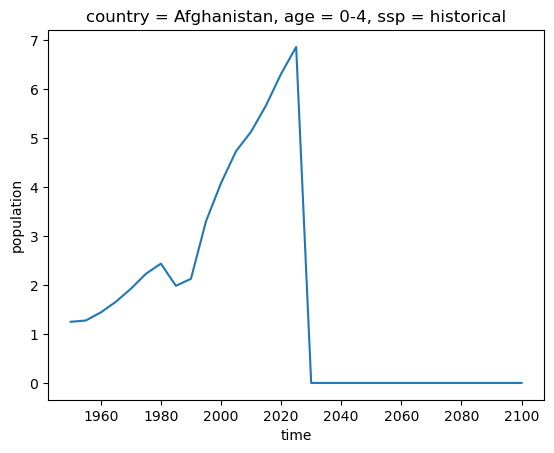

In [23]:
da.sel(ssp='historical', country='Afghanistan',age='0-4').sum(dim='sex').plot()

### test fxn (WCDE data)

In [3]:
flags

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024'}

In [4]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/UN_WPP2024'

In [5]:
# check WCDE data first

df_cohort_sizes, ages, years = load_cohort_sizes(dir_cohortsizes = os.path.join(data_dir, 'cohort-sizes/WCDE_v3.2.beta'),
                                                    data_source = 'WCDE', # 'WCDE' or 'UNWPP2024' 
                                                        ssp = 2,
                                                        by_sex = False,) 

loading cohort sizes from WCDE


In [6]:
df_cohort_sizes

<xarray.DataArray 'population' (country: 236, time: 31, age: 21)>
array([[[1.249598e+03, 9.540010e+02, 8.479810e+02, ..., 1.270000e-01,
         5.000000e-03, 0.000000e+00],
        [1.275876e+03, 1.062110e+03, 9.167520e+02, ..., 1.880000e-01,
         1.000000e-02, 0.000000e+00],
        [1.440271e+03, 1.093636e+03, 1.018713e+03, ..., 3.030000e-01,
         1.700000e-02, 0.000000e+00],
        ...,
        [6.332444e+03, 6.562508e+03, 6.998489e+03, ..., 1.450260e+02,
         2.017500e+01, 1.347000e+00],
        [6.170132e+03, 6.334755e+03, 6.561198e+03, ..., 1.840270e+02,
         2.751600e+01, 1.974000e+00],
        [5.976391e+03, 6.176918e+03, 6.337566e+03, ..., 2.249140e+02,
         3.629300e+01, 2.799000e+00]],

       [[1.839550e+02, 1.559470e+02, 1.424010e+02, ..., 9.080000e-01,
         1.500000e-01, 1.600000e-02],
        [2.309190e+02, 1.743350e+02, 1.537790e+02, ..., 1.680000e+00,
         2.800000e-01, 2.600000e-02],
        [2.890380e+02, 2.228960e+02, 1.746340e+02, ..., 3.002000e+00,
         4.410000e-01, 5.000000e-02],
...
        [2.758125e+03, 2.816799e+03, 2.908411e+03, ..., 7.242500e+01,
         1.265800e+01, 1.233000e+00],
        [2.671221e+03, 2.745646e+03, 2.811111e+03, ..., 9.179400e+01,
         1.618600e+01, 1.592000e+00],
        [2.585075e+03, 2.660460e+03, 2.740787e+03, ..., 1.190690e+02,
         2.111000e+01, 2.100000e+00]],

       [[4.761510e+02, 3.828150e+02, 3.160930e+02, ..., 3.470000e-01,
         5.200000e-02, 4.000000e-03],
        [6.402860e+02, 4.421300e+02, 3.746380e+02, ..., 4.350000e-01,
         5.900000e-02, 3.000000e-03],
        [7.324900e+02, 6.007910e+02, 4.334990e+02, ..., 4.870000e-01,
         7.400000e-02, 5.000000e-03],
        ...,
        [1.386299e+03, 1.451760e+03, 1.494274e+03, ..., 8.475600e+01,
         1.724800e+01, 2.347000e+00],
        [1.328739e+03, 1.379947e+03, 1.449082e+03, ..., 1.114820e+02,
         2.372400e+01, 2.795000e+00],
        [1.271387e+03, 1.324858e+03, 1.379785e+03, ..., 1.318940e+02,
         3.214000e+01, 3.960000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [7]:
ages

array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,
        67,  72,  77,  82,  87,  92,  97, 102])

In [8]:
years

array([1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000,
       2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055,
       2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100])

In [9]:
da = df_cohort_sizes

In [10]:
da.sel(country='Afghanistan').to_pandas().T

time,1950,1955,1960,1965,1970,1975,1980,1985,1990,1995,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
age,,,,,,,,,,,,,,,,,,,,,
2,1249.598,1275.876,1440.271,1657.766,1923.350,2229.691,2438.529,1984.951,2128.086,3302.788,...,8217.687,8136.818,8005.578,7744.366,7451.600,7018.162,6565.949,6332.444,6170.132,5976.391
7,954.001,1062.110,1093.636,1266.617,1476.636,1725.049,1905.433,1590.426,1622.083,2480.957,...,8167.990,8161.414,8088.521,7965.643,7714.048,7430.467,7006.311,6562.508,6334.755,6176.918
12,847.981,916.752,1018.713,1062.485,1233.340,1433.583,1582.033,1335.124,1390.359,1984.530,...,8033.591,8128.721,8125.283,8056.585,7938.613,7693.243,7415.788,6998.489,6561.198,6337.566
17,751.730,811.910,876.395,986.516,1031.631,1194.216,1310.253,1102.901,1166.653,1697.424,...,7804.234,7978.761,8081.695,8087.336,8028.349,7920.280,7685.320,7417.550,7009.684,6580.692
22,663.389,708.569,765.037,837.726,946.259,987.882,1078.048,892.458,943.803,1405.261,...,7442.725,7686.698,7864.888,7973.113,7985.126,7934.032,7834.237,7609.435,7351.711,6955.146
27,568.208,617.233,659.798,723.487,795.823,898.145,883.705,724.457,751.537,1126.579,...,6966.567,7308.440,7555.248,7738.782,7853.007,7872.464,7829.989,7739.729,7526.605,7280.564
32,487.298,524.196,570.358,619.671,683.032,751.196,799.741,590.222,608.275,895.322,...,6367.926,6848.340,7190.753,7441.175,7630.061,7750.914,7777.355,7743.173,7661.719,7459.397
37,416.301,444.182,479.103,530.351,579.707,639.376,664.331,530.935,493.473,722.408,...,5756.779,6259.134,6737.051,7080.722,7334.753,7529.362,7656.542,7690.001,7663.524,7590.224
42,353.457,374.167,400.737,440.224,490.679,537.164,559.966,438.479,440.306,583.378,...,5031.359,5649.756,6146.863,6622.754,6967.986,7226.474,7427.083,7561.322,7602.230,7583.917


## 1b. interpolate this new data

In [11]:
# test fxn 


da_cohort_size = interpolate_cohortsize_countries(df_cohort_sizes, ages, years, data_source = 'WCDE')

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 44, Comoros, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 74, Gabon, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 127, Mali, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 128, Malta, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 173, Rwanda, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 183, San Marino, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 198, South Sudan, setting them to zero
after interpolation and mean-preservi

In [12]:
da_cohort_size

<xarray.DataArray 'cohort_size' (country: 236, time: 151, ages: 105)>
array([[[2.73567360e+02, 2.61743480e+02, 2.49919600e+02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73309184e+02, 2.62139952e+02, 2.50970720e+02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73051008e+02, 2.62536424e+02, 2.52021840e+02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.19588425e+03, 1.20333086e+03, 1.21077748e+03, ...,
         2.38331824e-01, 0.00000000e+00, 0.00000000e+00],
        [1.18756014e+03, 1.19529399e+03, 1.20302784e+03, ...,
         2.56643380e-01, 0.00000000e+00, 0.00000000e+00],
        [1.17923604e+03, 1.18725712e+03, 1.19527820e+03, ...,
         2.74954937e-01, 0.00000000e+00, 0.00000000e+00]],

       [[3.90316400e+01, 3.79113200e+01, 3.67910000e+01, ...,
         1.99376947e-03, 0.00000000e+00, 0.00000000e+00],
        [4.13674160e+01, 4.00184880e+01, 3.86695600e+01, ...,
         2.18182113e-03, 0.00000000e+00, 0.00000000e+00],
        [4.37031920e+01, 4.21256560e+01, 4.05481200e+01, ...,
         2.36987279e-03, 0.00000000e+00, 0.00000000e+00],
...
        [5.17906600e+02, 5.20906640e+02, 5.23906680e+02, ...,
         2.24356300e-01, 0.00000000e+00, 0.00000000e+00],
        [5.14445400e+02, 5.17453120e+02, 5.20460840e+02, ...,
         2.36712206e-01, 0.00000000e+00, 0.00000000e+00],
        [5.10984200e+02, 5.13999600e+02, 5.17015000e+02, ...,
         2.49068113e-01, 0.00000000e+00, 0.00000000e+00]],

       [[1.02697080e+02, 9.89636400e+01, 9.52302000e+01, ...,
         3.92156863e-04, 0.00000000e+00, 0.00000000e+00],
        [1.10939600e+02, 1.06367600e+02, 1.01795600e+02, ...,
         3.55979011e-04, 0.00000000e+00, 0.00000000e+00],
        [1.19182120e+02, 1.13771560e+02, 1.08361000e+02, ...,
         3.19801160e-04, 0.00000000e+00, 0.00000000e+00],
        ...,
        [2.54660296e+02, 2.56762928e+02, 2.58865560e+02, ...,
         4.76045919e-01, 0.00000000e+00, 0.00000000e+00],
        [2.52330008e+02, 2.54450744e+02, 2.56571480e+02, ...,
         5.10386444e-01, 0.00000000e+00, 0.00000000e+00],
        [2.49999720e+02, 2.52138560e+02, 2.54277400e+02, ...,
         5.44726970e-01, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

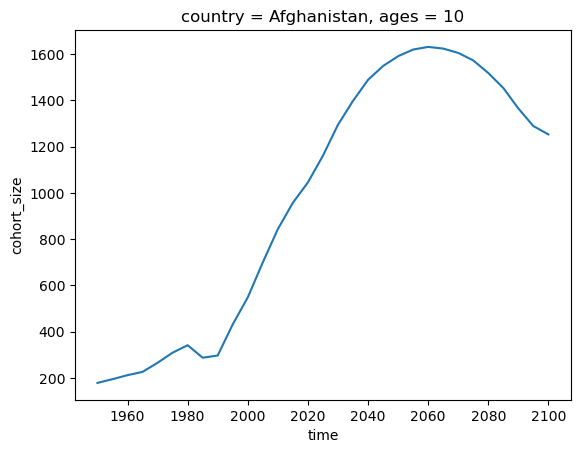

In [13]:
da_cohort_size.sel(country='Afghanistan', ages=10).astype(float).plot()

# check the units !!!! 

In [14]:
da_cohort_size_wcde = da_cohort_size

## 1c. try loading the new UNWPP2024 cohort size data 

In [6]:
filepath_cohortsizes = os.path.join(dir_cohortsizes, 'WPP2024_POP_F01_1_POPULATION_SINGLE_AGE_BOTH_SEXES.xlsx')
filepath_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/UN_WPP2024/WPP2024_POP_F01_1_POPULATION_SINGLE_AGE_BOTH_SEXES.xlsx'

In [ ]:
df_cohort_sizes_unwpp, ages, years = load_cohort_sizes(dir_cohortsizes =  dir_cohortsizes, 
                                                    ssp=None, 
                                                    data_source = 'UNWPP2024',
                                                    by_sex=False)

loading cohort sizes from UNWPP2024


In [8]:
df_cohort_sizes_unwpp

<xarray.DataArray (ages: 100, country: 237, time: 151)>
array([[[3.1581850e+02, 3.1596150e+02, 3.2254100e+02, ...,
         1.8121300e+03, 1.8078235e+03, 1.8011550e+03],
        [4.4996000e+01, 4.7037000e+01, 4.9370500e+01, ...,
         7.3635000e+00, 7.2780000e+00, 7.1850000e+00],
        [3.7315250e+02, 4.0705050e+02, 4.1599500e+02, ...,
         6.0000900e+02, 5.9824750e+02, 5.9676000e+02],
        ...,
        [1.9274850e+02, 1.9069000e+02, 1.9590250e+02, ...,
         1.3801885e+03, 1.3714585e+03, 1.3632210e+03],
        [1.0203000e+02, 1.0746950e+02, 1.1039450e+02, ...,
         9.2323600e+02, 9.2014900e+02, 9.1798000e+02],
        [1.2761300e+02, 1.3197050e+02, 1.3534650e+02, ...,
         5.0170500e+02, 4.9895500e+02, 4.9595450e+02]],

       [[2.6917450e+02, 2.6723850e+02, 2.6814350e+02, ...,
         1.8131700e+03, 1.8097570e+03, 1.8048325e+03],
        [3.9432000e+01, 4.0547500e+01, 4.2429500e+01, ...,
         7.4565000e+00, 7.3585000e+00, 7.2730000e+00],
        [3.0553350e+02, 3.4287700e+02, 3.7440050e+02, ...,
         6.0132050e+02, 5.9920000e+02, 5.9751500e+02],
...
        [1.5500000e-02, 1.2500000e-02, 1.0000000e-02, ...,
         7.5390000e+00, 7.9440000e+00, 8.3665000e+00],
        [4.0000000e-03, 4.5000000e-03, 4.0000000e-03, ...,
         4.6720000e+00, 4.9775000e+00, 5.3015000e+00],
        [7.5000000e-03, 7.5000000e-03, 5.5000000e-03, ...,
         4.3135000e+00, 4.6890000e+00, 5.0470000e+00]],

       [[5.0000000e-04, 5.0000000e-04, 0.0000000e+00, ...,
         3.9200000e+00, 4.1835000e+00, 4.4495000e+00],
        [1.0500000e-02, 9.0000000e-03, 8.0000000e-03, ...,
         4.1160000e+00, 4.0945000e+00, 3.9620000e+00],
        [1.5300000e-01, 1.4550000e-01, 1.2700000e-01, ...,
         4.4002000e+01, 4.5875500e+01, 4.7732500e+01],
        ...,
        [9.5000000e-03, 9.0000000e-03, 7.5000000e-03, ...,
         4.6705000e+00, 4.9535000e+00, 5.2310000e+00],
        [2.5000000e-03, 3.0000000e-03, 3.5000000e-03, ...,
         3.0565000e+00, 3.2730000e+00, 3.4925000e+00],
        [4.5000000e-03, 5.0000000e-03, 5.5000000e-03, ...,
         2.8000000e+00, 3.1050000e+00, 3.3800000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 9 ... 90 91 92 93 94 95 96 97 98 99

### extrapolate 

In [15]:

#set new coordinates for after interpolation - check you want this & put in flags at start or something !! 
ages_interpn_cohorts =  np.arange(0,105) 
years_interpn_cohorts = np.arange(1950,2119+1)

da_cohort_size_unwpp = df_cohort_sizes_unwpp.reindex(time=years_interpn_cohorts, ages=ages_interpn_cohorts, method="ffill").rename('cohort_size')

In [16]:
da_cohort_size_unwpp = da_cohort_size_unwpp.transpose("country", "time", "ages") 

<Axes: xlabel='time'>

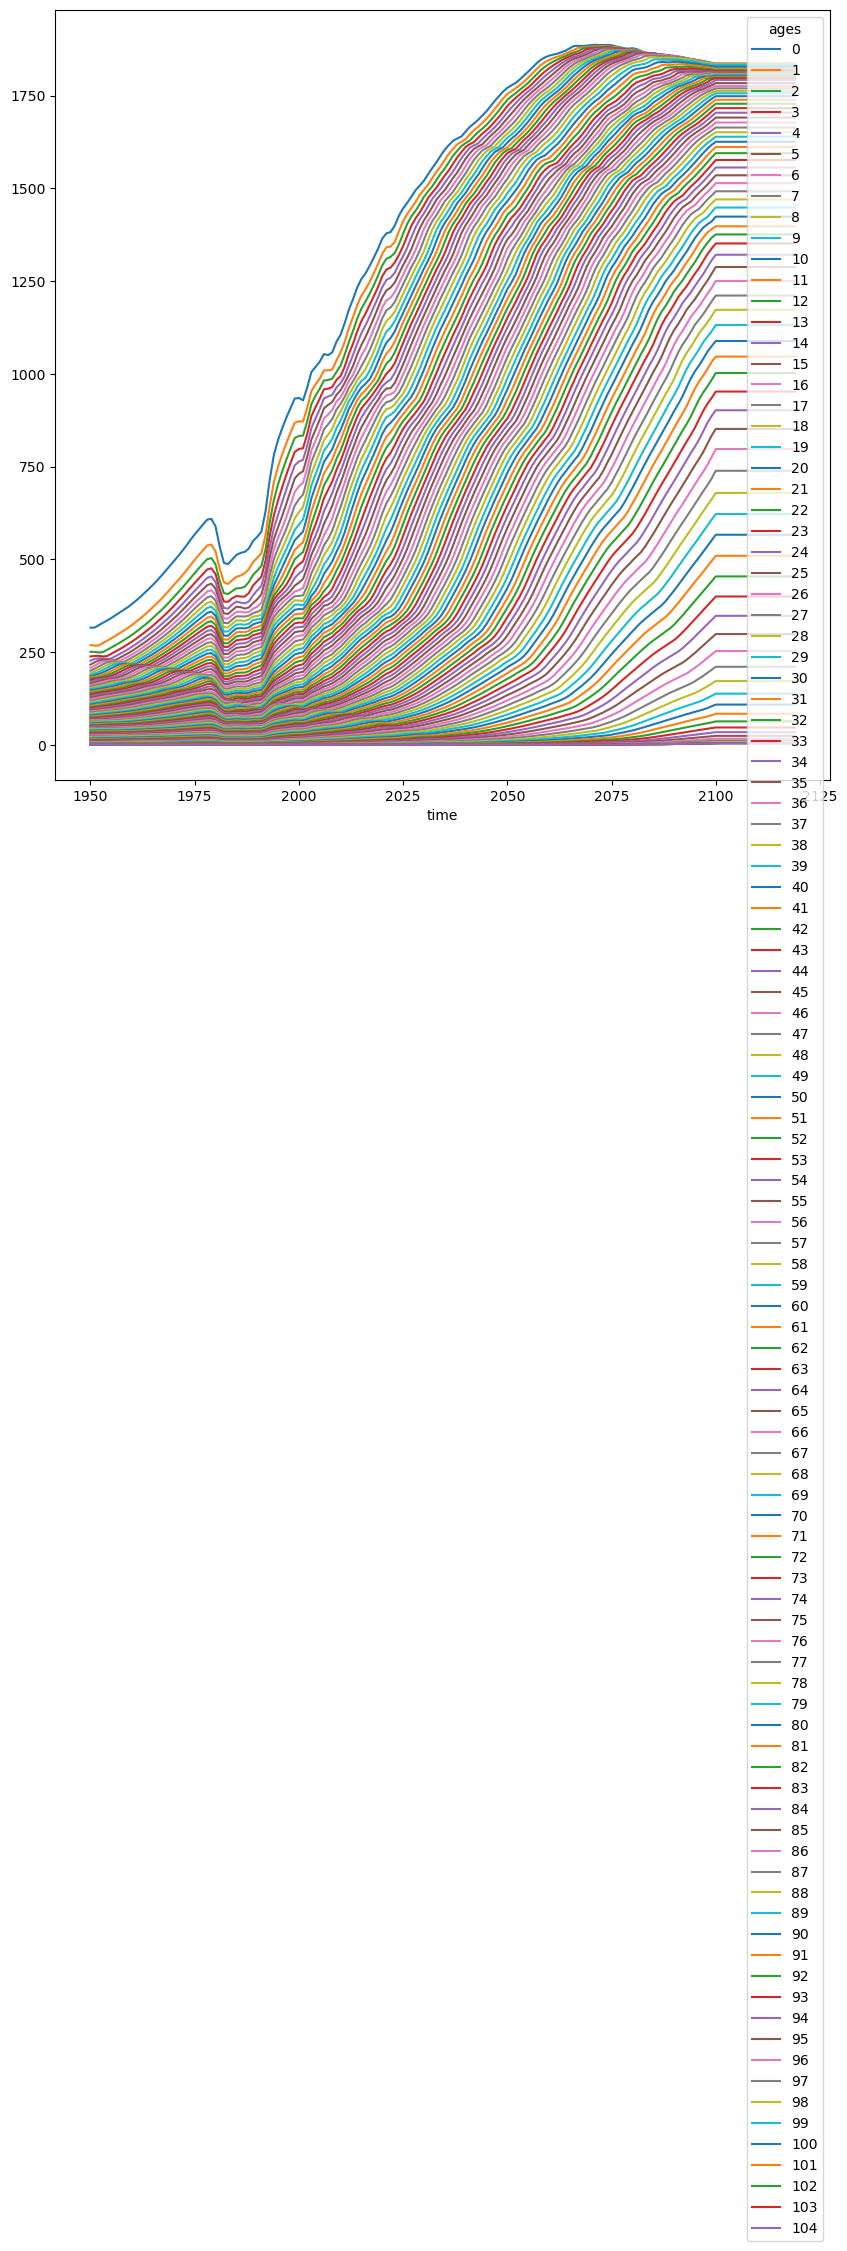

In [18]:
da_cohort_size_unwpp.sel(country='Afghanistan').to_pandas().plot(figsize=(10,10)) # linear

In [21]:
da_cohort_size = interpolate_cohortsize_countries(
    da_cohortsizes_raw,
    ages,
    years,
    data_source = 'UNWPP2024'
)

In [25]:
da_cohort_size_unwpp = da_cohort_size

In [22]:
da_cohort_size

<xarray.DataArray 'cohort_size' (ages: 100, country: 237, time: 151)>
array([[[315.8185, 315.9615, 322.541, ..., 1812.13, 1807.8235, 1801.155],
        [44.996, 47.037, 49.3705, ..., 7.3635, 7.278, 7.185],
        [373.1525, 407.0505, 415.995, ..., 600.009, 598.2475, 596.76],
        ...,
        [192.7485, 190.69, 195.9025, ..., 1380.1885, 1371.4585,
         1363.221],
        [102.03, 107.4695, 110.3945, ..., 923.236, 920.149, 917.98],
        [127.613, 131.9705, 135.3465, ..., 501.705, 498.955, 495.9545]],

       [[269.1745, 267.2385, 268.1435, ..., 1813.17, 1809.757,
         1804.8325],
        [39.432, 40.5475, 42.4295, ..., 7.4565, 7.3585, 7.273],
        [305.5335, 342.877, 374.4005, ..., 601.3205, 599.2, 597.515],
        ...,
        [157.971, 152.821, 151.7765, ..., 1385.3305, 1377.5645,
         1368.784],
        [88.6005, 94.7415, 99.925, ..., 924.226, 920.8885, 917.8325],
        [104.1235, 120.778, 125.039, ..., 501.418, 499.083, 496.3305]],

       [[250.507, 250.435, 248.891, ..., 1814.529, 1811.475, 1807.489],
...
        ...,
        [0.022, 0.017, 0.013, ..., 11.6875, 12.283, 12.985],
        [0.0065, 0.0055, 0.004, ..., 6.921, 7.36, 7.845],
        [0.011, 0.008, 0.0065, ..., 6.352, 6.828, 7.301]],

       [[0.0015, 0.001, 0, ..., 6.36, 6.752, 7.1515],
        [0.016, 0.014, 0.0125, ..., 5.152, 4.9755, 4.602],
        [0.241, 0.21, 0.152, ..., 58.9905, 61.2625, 62.838],
        ...,
        [0.0155, 0.0125, 0.01, ..., 7.539, 7.944, 8.3665],
        [0.004, 0.0045, 0.004, ..., 4.672, 4.9775, 5.3015],
        [0.0075, 0.0075, 0.0055, ..., 4.3135, 4.689, 5.047]],

       [[0.0005, 0.0005, 0, ..., 3.92, 4.1835, 4.4495],
        [0.0105, 0.009, 0.008, ..., 4.116, 4.0945, 3.962],
        [0.153, 0.1455, 0.127, ..., 44.002, 45.8755, 47.7325],
        ...,
        [0.0095, 0.009, 0.0075, ..., 4.6705, 4.9535, 5.231],
        [0.0025, 0.003, 0.0035, ..., 3.0565, 3.273, 3.4925],
        [0.0045, 0.005, 0.0055, ..., 2.8, 3.105, 3.38]]], dtype=object)
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 9 ... 90 91 92 93 94 95 96 97 98 99

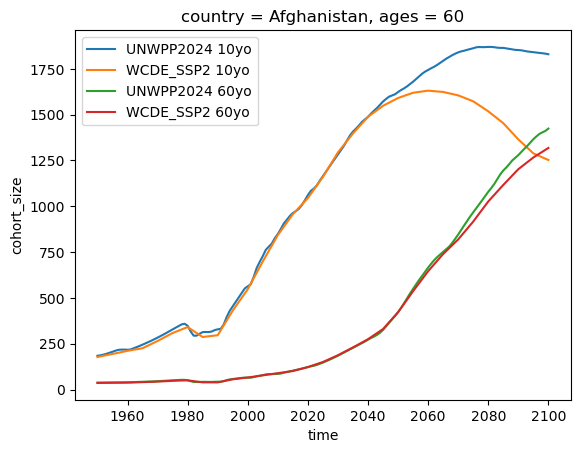

In [31]:
fig,ax = plt.subplots()

da_cohort_size_unwpp.sel(country='Afghanistan', ages=10).astype(float).plot(ax=ax, label='UNWPP2024 10yo')
da_cohort_size_wcde.sel(country='Afghanistan', ages=10).plot(ax=ax, label='WCDE_SSP2 10yo')

da_cohort_size_unwpp.sel(country='Afghanistan', ages=60).astype(float).plot(ax=ax, label='UNWPP2024 60yo')
da_cohort_size_wcde.sel(country='Afghanistan', ages=60).plot(ax=ax, label='WCDE_SSP2 60yo')

plt.legend()

Text(0, 0.5, 'global population (billions)')

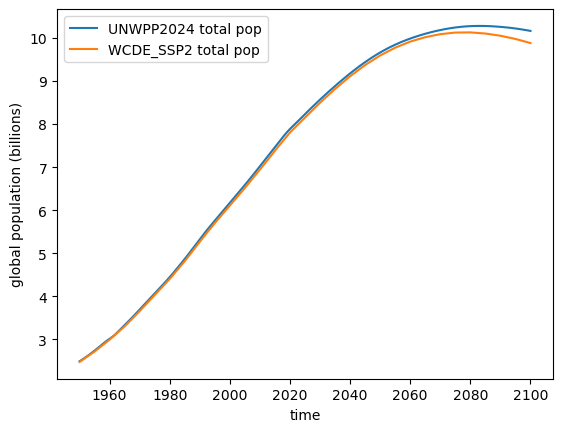

In [ ]:
fig,ax = plt.subplots()

# original units = thousands dive by 1e6 -> millions -> billions

(da_cohort_size_unwpp.sum(dim=['country', 'ages']) / 1e6 ).astype(float).plot(ax=ax, label='UNWPP2024 total pop')
(da_cohort_size_wcde.sum(dim=['country', 'ages']) / 1e6).plot(ax=ax, label='WCDE_SSP2 total pop')

#da_cohort_size_unwpp.sel(country='Afghanistan', ages=60).astype(float).plot(ax=ax, label='UNWPP2024 60yo')
#da_cohort_size_wcde.sel(country='Afghanistan', ages=60).plot(ax=ax, label='WCDE_SSP2 60yo')

plt.legend()

plt.ylabel('global population (billions)')

# UNWPP2024 has a slightly higher population

Text(0, 0.5, 'global cohort size (billions)')

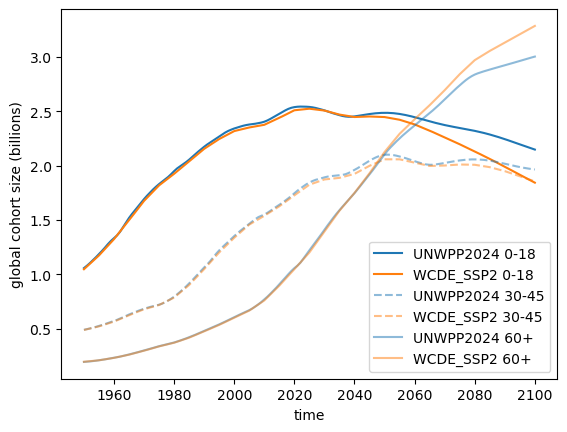

In [ ]:
fig,ax = plt.subplots()

factor = 1e6 

(da_cohort_size_unwpp / factor).sum(dim='country').sel(ages=slice(0,18)).sum(dim='ages').astype(float).plot(ax=ax, label='UNWPP2024 0-18')
(da_cohort_size_wcde / factor).sum(dim='country').sel(ages=slice(0,18)).sum(dim='ages').astype(float).plot(ax=ax, label='WCDE_SSP2 0-18')

(da_cohort_size_unwpp / factor).sum(dim='country').sel(ages=slice(30,45)).sum(dim='ages').astype(float).plot(ax=ax, label='UNWPP2024 30-45', c='C0',ls='--',alpha=.5)
(da_cohort_size_wcde / factor).sum(dim='country').sel(ages=slice(30,45)).sum(dim='ages').astype(float).plot(ax=ax, label='WCDE_SSP2 30-45',c='C1',ls='--',alpha=.5)

(da_cohort_size_unwpp / factor).sum(dim='country').sel(ages=slice(60,101)).sum(dim='ages').astype(float).plot(ax=ax, label='UNWPP2024 60+', c='C0',alpha=.5)
(da_cohort_size_wcde / factor).sum(dim='country').sel(ages=slice(60,101)).sum(dim='ages').astype(float).plot(ax=ax, label='WCDE_SSP2 60+',c='C1',alpha=.5)


plt.legend()
plt.ylabel('global cohort size (billions)')

# SSP2 seems to be slightly older globally, compared to UNWPP2024



In [ ]:
# put this in the functions!! as an option

In [ ]:
# check with the old data !! compare same units - its not the same units 


#### filtering countries with UNWPP2024

In [24]:
da_cohort_size_unwpp

<xarray.DataArray 'cohort_size' (country: 237, time: 170, ages: 105)>
array([[[3.1581850e+02, 2.6917450e+02, 2.5050700e+02, ...,
         5.0000000e-04, 5.0000000e-04, 5.0000000e-04],
        [3.1596150e+02, 2.6723850e+02, 2.5043500e+02, ...,
         5.0000000e-04, 5.0000000e-04, 5.0000000e-04],
        [3.2254100e+02, 2.6814350e+02, 2.4889100e+02, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         4.4495000e+00, 4.4495000e+00, 4.4495000e+00],
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         4.4495000e+00, 4.4495000e+00, 4.4495000e+00],
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         4.4495000e+00, 4.4495000e+00, 4.4495000e+00]],

       [[4.4996000e+01, 3.9432000e+01, 3.5923000e+01, ...,
         1.0500000e-02, 1.0500000e-02, 1.0500000e-02],
        [4.7037000e+01, 4.0547500e+01, 3.7188500e+01, ...,
         9.0000000e-03, 9.0000000e-03, 9.0000000e-03],
        [4.9370500e+01, 4.2429500e+01, 3.8437000e+01, ...,
         8.0000000e-03, 8.0000000e-03, 8.0000000e-03],
...
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         3.4925000e+00, 3.4925000e+00, 3.4925000e+00],
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         3.4925000e+00, 3.4925000e+00, 3.4925000e+00],
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         3.4925000e+00, 3.4925000e+00, 3.4925000e+00]],

       [[1.2761300e+02, 1.0412350e+02, 8.7942000e+01, ...,
         4.5000000e-03, 4.5000000e-03, 4.5000000e-03],
        [1.3197050e+02, 1.2077800e+02, 1.0069000e+02, ...,
         5.0000000e-03, 5.0000000e-03, 5.0000000e-03],
        [1.3534650e+02, 1.2503900e+02, 1.1691000e+02, ...,
         5.5000000e-03, 5.5000000e-03, 5.5000000e-03],
        ...,
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         3.3800000e+00, 3.3800000e+00, 3.3800000e+00],
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         3.3800000e+00, 3.3800000e+00, 3.3800000e+00],
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         3.3800000e+00, 3.3800000e+00, 3.3800000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [25]:
df_life_expectancy_5

Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Wallis and Futuna Islands,Western Sahara,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,73.0935,78.4736,60.3326,71.0196,72.9259,73.986,73.5868,...,76.9994,71.5994,62.5983,68.7405,68.7827,60.0066,58.8167,63.0338,68.3711,67.5054
1951,54.9914,73.117,59.9968,73.3142,78.7848,60.4601,71.3453,73.1271,74.8442,73.7835,...,77.1543,71.7428,63.0074,69.2576,69.2194,60.2678,59.0545,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,73.5873,79.0685,60.5222,71.6498,73.3441,74.3825,73.9763,...,77.303,71.891,63.3789,69.761,69.5801,60.5338,59.2911,63.3482,68.714,67.9825
1953,55.6465,75.0774,59.7686,74.0095,79.449,60.5925,71.9511,73.5912,75.4063,74.1662,...,77.4524,72.0515,63.7587,70.2772,69.953,60.8083,59.5263,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,74.5568,79.7661,60.6646,72.3025,73.8626,75.209,74.3545,...,77.5948,72.2161,64.1316,70.8107,70.2969,61.0874,59.7591,63.7344,69.1736,68.4717
1955,56.2518,76.5891,59.5298,75.0851,80.1218,60.7478,71.4231,74.0973,75.3088,74.5424,...,77.7112,72.3857,64.497,71.2998,70.7099,61.3774,59.9861,63.9845,69.3474,68.7514
1956,56.5746,76.9806,59.4297,75.4831,80.4959,58.9827,72.9037,74.4576,75.6636,74.7311,...,77.8104,72.54,64.8439,71.8403,70.9153,61.6823,60.2073,64.2225,69.5762,69.0324
1957,56.8662,77.3068,58.1319,75.6528,80.8279,59.0979,73.1615,74.7743,75.5765,74.9164,...,77.8888,72.7043,65.182,72.186,70.556,62.0178,60.4371,63.0699,69.7255,69.3188
1958,57.1442,77.6003,62.5451,75.6224,81.0699,59.1849,73.4077,75.1173,75.7557,75.0945,...,77.964,72.8695,65.5151,72.8415,69.2959,62.361,60.6635,62.1884,69.872,69.6035


In [28]:
df_life_expectancy_5.columns.tolist()

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Bonaire, Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'China, Hong Kong SAR',
 'China, Macao SAR',
 'China, Taiwan Province of China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 "Côte d'Ivoire",
 "Dem. People's Republic of Korea",
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dom

In [33]:
da_cohort_size_unwpp.country.values.tolist()

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Bonaire, Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'China, Hong Kong SAR',
 'China, Macao SAR',
 'China, Taiwan Province of China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 "Côte d'Ivoire",
 "Dem. People's Republic of Korea",
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dom

In [34]:
df_life_expectancy_5.columns.tolist() == da_cohort_size_unwpp.country.values.tolist()

True

## 2. Load new population data

In [2]:
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [3]:
dir_population

'/data/brussel/vo/000/bvo00012/data/dataset/COMPASS/v2/population_count/01deg'

In [8]:
da_population = load_population()

opening compass - historical
opening compass - ssp2


In [5]:
da_population

<xarray.DataArray 'Population_count' (time: 151, lat: 1800, lon: 3600)>
dask.array<concatenate, shape=(151, 1800, 3600), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:      1
    long_name:  Population_count

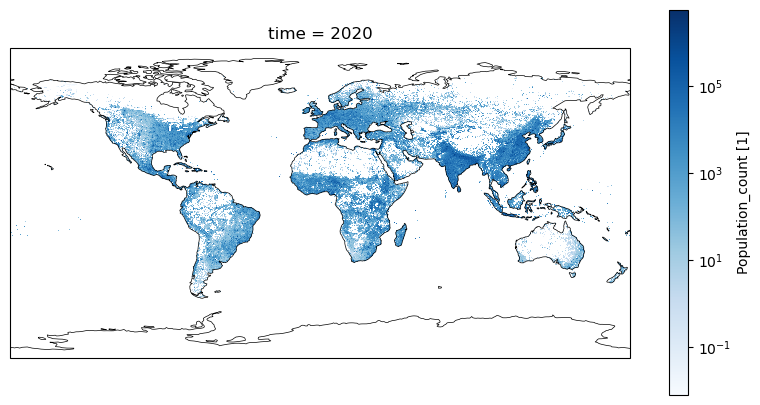

In [8]:
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature



da = da_population.sel(time=2020)

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(10, 5)
)

da.where(da>.000001).plot(norm=LogNorm(), cmap='Blues', ax=ax)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)


In [9]:
da_population

<xarray.DataArray 'Population_count' (time: 151, lat: 1800, lon: 3600)>
dask.array<concatenate, shape=(151, 1800, 3600), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:      1
    long_name:  Population_count

In [24]:
# test the bbox - ok works! 


da_population_portugal = load_population(
    dir_population= dir_population, 
    startyear=1950,
    endyear=2100,
    ssp=2,
    urbanrural=False,
    chunksize=100,
    bbox = [32.75, 42.25,  -28.75, -6.25]

)

opening compass - historical
opening compass - ssp2


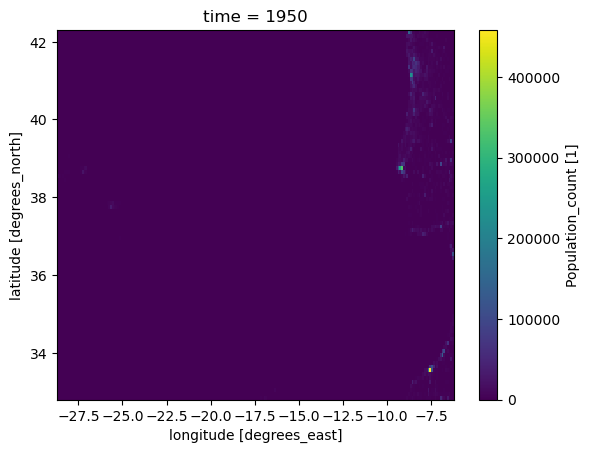

In [25]:
da_population_portugal.isel(time=0).plot()

In [10]:
#testing old version still works 


# flags['version']=1
# dir_population = os.path.join(script_dir, 'data/gridded-pop/') 
# da_population = load_population(dir_population)

In [11]:
# da_population

## 3. new lookup table? 

Masks - cohort data (SSP) already matched - but im not using this !

To do: 
- match life expectancy data name 
    - Just match based on SDMX code = ISO numeric! This is available in UNWPP2024 data! ?? > make this index in da_cohorts? or add column here to the lookup table with the names in UNWPP ! 
    - Done, as 'WPP name' 
- Add the original country mask name from ISIPEDIA as well ! Based on ISO-3 check overlap 
- Check overlap also with SSP cohort size projections
    - ok, correct but 35 countries dont have cohort size projections - decide what to do about this / how much does it matter? 

### check it 

In [5]:
df_lookuptable = pd.read_excel(filepath_lookuptable_original)

In [6]:
df_lookuptable

,SSP name,ISO name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill
0,Afghanistan,Afghanistan,AF,AFG,4,Full historical + SSP,NaN
1,Albania,Albania,AL,ALB,8,Full historical + SSP,NaN
2,Algeria,Algeria,DZ,DZA,12,Full historical + SSP,NaN
3,Angola,Angola,AO,AGO,24,Full historical + SSP,NaN
4,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28,Full historical + SSP,NaN
...,...,...,...,...,...,...,...
244,NaN,Norfolk Island,NF,NFK,574,No data,Rest of Asia (R10)
245,NaN,Pitcairn,PN,PCN,612,No data,Rest of Asia (R10)
246,NaN,South Georgia and the South Sandwich Islands,GS,SGS,239,No population,NaN
247,NaN,Svalbard and Jan Mayen,SJ,SJM,744,No data,Europe (R10)


In [8]:
filepath_lifeexpectancy = os.path.join(data_dir, 'life-expectancy/UN_WPP2024/WPP2024_MORT_F05_1_LIFE_EXPECTANCY_BY_AGE_BOTH_SEXES.xlsx')

df_unwpp_raw = pd.read_excel(filepath_lifeexpectancy, 
             sheet_name=0,
             skiprows=16)

In [22]:
df_unwpp = df_unwpp_raw[df_unwpp_raw['Type']=='Country/Area'].rename(
              columns={'Region, subregion, country or area *':'WPP name', 'SDMX code**':'ISO numeric'}) # make this more flex 
cols = df_unwpp.columns
idxs = [i for i, col in enumerate(cols) if col in ('WPP name', 'ISO numeric')] #  'ISO3 Alpha-code'
df_unwpp = df_unwpp.iloc[:, idxs].drop_duplicates()
df_unwpp['ISO numeric'] = df_unwpp['ISO numeric'].astype(int)

df_unwpp

,WPP name,ISO numeric
2594,Burundi,108
2668,Comoros,174
2742,Djibouti,262
2816,Eritrea,232
2890,Ethiopia,231
...,...,...
21686,Samoa,882
21760,Tokelau,772
21834,Tonga,776
21908,Tuvalu,798


In [41]:
cols = df_lookuptable.columns.values
new_cols = list(cols[:2]) + ['WPP name'] + list(cols[2:])
new_cols
df_lookuptable_new = df_lookuptable.merge(df_unwpp, how='outer', on='ISO numeric').loc[:, new_cols]

In [42]:
diff_mask = df_lookuptable_new['SSP name'] != df_lookuptable_new['WPP name']
df_differences = df_lookuptable_new[diff_mask][['ISO numeric', 'SSP name', 'WPP name']]
df_differences

,ISO numeric,SSP name,WPP name
20,68,Bolivia,Bolivia (Plurinational State of)
78,344,Hong Kong,"China, Hong Kong SAR"
83,364,Iran,Iran (Islamic Republic of)
94,412,Kosovo,Kosovo (under UNSC res. 1244)
97,418,Laos,Lao People's Democratic Republic
105,446,Macao,"China, Macao SAR"
117,583,Micronesia,Micronesia (Fed. States of)
118,498,Moldova,Republic of Moldova
132,408,North Korea,Dem. People's Republic of Korea
137,275,Palestine,State of Palestine


In [ ]:
#df_lookuptable_new.to_csv('../data/country-masks/lookup_table_dem4cli_v2.csv', index=False)

### Check mask ISO3 is same as in lookup table

In [ ]:
df_lookuptable = pd.read_csv(filepath_lookuptable) # new one with WPP name added! 

In [4]:
df_lookuptable

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4,Full historical + SSP,NaN
1,Albania,Albania,Albania,AL,ALB,8,Full historical + SSP,NaN
2,Algeria,Algeria,Algeria,DZ,DZA,12,Full historical + SSP,NaN
3,Angola,Angola,Angola,AO,AGO,24,Full historical + SSP,NaN
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28,Full historical + SSP,NaN
...,...,...,...,...,...,...,...,...
244,NaN,Norfolk Island,NaN,NF,NFK,574,No data,Rest of Asia (R10)
245,NaN,Pitcairn,NaN,PN,PCN,612,No data,Rest of Asia (R10)
246,NaN,South Georgia and the South Sandwich Islands,NaN,GS,SGS,239,No population,NaN
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744,No data,Europe (R10)


In [5]:
# add/check countrymask availability info 
da_countrymasks = load_countrymasks_fillcoasts(
    filepath_countrymask=filepath_countrymask,
    fillcoast=False,
    fix_smallislands=False, # fix this for flexible resolution! 
    bbox=None,)


In [6]:
da_countrymasks

<xarray.DataArray (lat: 1800, lon: 3600, country: 225)>
dask.array<getitem, shape=(1800, 3600, 225), dtype=float32, chunksize=(519, 1040, 62), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.6 ... 179.8 179.9 180.0
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

In [8]:
df = df_lookuptable.merge(pd.DataFrame(da_countrymasks.country.to_pandas().rename('iso3_mask')), how='outer', left_on='ISO alpha-3', right_on='country')

In [9]:
df

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744.0,No data,Europe (R10),SJM
248,NaN,United States Minor Outlying Islands,NaN,UM,UMI,581.0,No population,NaN,NaN
249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSID
250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IOSID


In [ ]:
df[df["ISO alpha-3"] != df['iso3_mask']].reset_index()

# where the mask and iso alpha-3 dont match : missing in mask 
# only 3 had full data in other fields (Aruba, Kosovo, Macao), others were missing ther data

,index,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,7,Aruba,Aruba,Aruba,AW,ABW,533.0,Full historical + SSP,NaN,NaN
1,94,Kosovo,Kosovo,Kosovo (under UNSC res. 1244),XK,XKX,412.0,Full historical + SSP,NaN,NaN
2,105,Macao,Macao,"China, Macao SAR",MO,MAC,446.0,Full historical + SSP,NaN,NaN
3,203,Anguilla,Anguilla,Anguilla,AI,AIA,660.0,Only historical until 2015,Latin America (R10),NaN
4,205,"Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba",BQ,BES,535.0,Only historical until 2015,Latin America (R10),NaN
5,208,Cook Islands,Cook Islands,Cook Islands,CK,COK,184.0,Only historical until 2015,Rest of Asia (R10),NaN
6,212,Gibraltar,Gibraltar,Gibraltar,GI,GIB,292.0,Only historical until 2015,Europe (R10),NaN
7,214,Guernsey,Guernsey,Guernsey,GG,GGY,831.0,Only historical until 2015,Europe (R10),NaN
8,216,Jersey,Jersey,Jersey,JE,JEY,832.0,Only historical until 2015,Europe (R10),NaN
9,217,Liechtenstein,Liechtenstein,Liechtenstein,LI,LIE,438.0,Only historical until 2015,Europe (R10),NaN


In [13]:
df['WPP name'][df['WPP name'].notna()].reset_index()

,index,WPP name
0,0,Afghanistan
1,1,Albania
2,2,Algeria
3,3,Angola
4,4,Antigua and Barbuda
...,...,...
232,232,Tokelau
233,233,Turks and Caicos Islands
234,234,Tuvalu
235,235,Wallis and Futuna Islands


In [ ]:
df['SSP name'][df['SSP name'].notna()].reset_index()

# 236 countries in UNWPP data

,index,SSP name
0,0,Afghanistan
1,1,Albania
2,2,Algeria
3,3,Angola
4,4,Antigua and Barbuda
...,...,...
231,231,Sint Maarten (Dutch part)
232,232,Tokelau
233,233,Turks and Caicos Islands
234,234,Tuvalu


In [ ]:
df[df[["SSP name", "WPP name", 'iso3_mask']].notna().all(axis=1)].reset_index(drop=True).tail(40)

# overlap of SSPs, UNWPP and mask = 218 countries 

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
178,Tonga,Tonga,Tonga,TO,TON,776.0,Full historical + SSP,NaN,TON
179,Trinidad and Tobago,Trinidad and Tobago,Trinidad and Tobago,TT,TTO,780.0,Full historical + SSP,NaN,TTO
180,Tunisia,Tunisia,Tunisia,TN,TUN,788.0,Full historical + SSP,NaN,TUN
181,Turkey,Turkey,Türkiye,TR,TUR,792.0,Full historical + SSP,NaN,TUR
182,Turkmenistan,Turkmenistan,Turkmenistan,TM,TKM,795.0,Full historical + SSP,NaN,TKM
183,Uganda,Uganda,Uganda,UG,UGA,800.0,Full historical + SSP,NaN,UGA
184,Ukraine,Ukraine,Ukraine,UA,UKR,804.0,Full historical + SSP,NaN,UKR
185,United Arab Emirates,United Arab Emirates,United Arab Emirates,AE,ARE,784.0,Full historical + SSP,NaN,ARE
186,United Kingdom,United Kingdom of Great Britain and Northern I...,United Kingdom,GB,GBR,826.0,Full historical + SSP,NaN,GBR
187,United States,United States of America,United States of America,US,USA,840.0,Full historical + SSP,NaN,USA


In [15]:
df[df[["SSP name", "WPP name", 'iso3_mask']].isna().any(axis=1)].reset_index(drop=True)

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Aruba,Aruba,Aruba,AW,ABW,533.0,Full historical + SSP,NaN,NaN
1,Kosovo,Kosovo,Kosovo (under UNSC res. 1244),XK,XKX,412.0,Full historical + SSP,NaN,NaN
2,Macao,Macao,"China, Macao SAR",MO,MAC,446.0,Full historical + SSP,NaN,NaN
3,Anguilla,Anguilla,Anguilla,AI,AIA,660.0,Only historical until 2015,Latin America (R10),NaN
4,"Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba",BQ,BES,535.0,Only historical until 2015,Latin America (R10),NaN
5,Cook Islands,Cook Islands,Cook Islands,CK,COK,184.0,Only historical until 2015,Rest of Asia (R10),NaN
6,Gibraltar,Gibraltar,Gibraltar,GI,GIB,292.0,Only historical until 2015,Europe (R10),NaN
7,Guernsey,Guernsey,Guernsey,GG,GGY,831.0,Only historical until 2015,Europe (R10),NaN
8,Jersey,Jersey,Jersey,JE,JEY,832.0,Only historical until 2015,Europe (R10),NaN
9,Liechtenstein,Liechtenstein,Liechtenstein,LI,LIE,438.0,Only historical until 2015,Europe (R10),NaN


In [ ]:
218+34 # notna + anyna = all 

252

### Check overlap with SSP projs

yes all good - Dominik mapped names correctly

But there are 35 countries with projections missing that are in cohsize! As Dominik marked in table! remove them? 

In [17]:
df_cohort_sizes, ages, years = load_cohort_sizes(dir_cohortsizes, ssp=2, by_sex=False)
df_cohort_sizes

<xarray.DataArray 'population' (country: 236, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [ ]:
#df_cohort_sizes.sel(country != 'World')

<xarray.DataArray 'population' (country: 237, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102
Dimensions without coordinates: country

In [19]:
df_merge = df.merge(pd.DataFrame(df_cohort_sizes.country.to_pandas().rename('name wcde')), how='outer', left_on='SSP name', right_on='country')

In [20]:
df_merge

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask,name wcde
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG,Afghanistan
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB,Albania
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA,Algeria
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO,Angola
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG,Antigua and Barbuda
...,...,...,...,...,...,...,...,...,...,...
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744.0,No data,Europe (R10),SJM,NaN
248,NaN,United States Minor Outlying Islands,NaN,UM,UMI,581.0,No population,NaN,NaN,NaN
249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSID,NaN
250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IOSID,NaN


In [22]:
df_merge[df_merge["SSP name"] != df_merge['name wcde']].reset_index(drop=True)

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask,name wcde
0,NaN,Antarctica,NaN,AQ,ATA,10.0,No population,NaN,NaN,NaN
1,NaN,Bouvet Island,NaN,BV,BVT,74.0,No population,NaN,NaN,NaN
2,NaN,British Indian Ocean Territory,NaN,IO,IOT,86.0,No population,NaN,NaN,NaN
3,NaN,Christmas Island,NaN,CX,CXR,162.0,No data,Rest of Asia (R10),NaN,NaN
4,NaN,Cocos (Keeling) Islands,NaN,CC,CCK,166.0,No data,Rest of Asia (R10),NaN,NaN
5,NaN,French Southern Territories,NaN,TF,ATF,260.0,No population,NaN,ATF,NaN
6,NaN,Heard Island and McDonald Islands,NaN,HM,HMD,334.0,No population,NaN,HMD,NaN
7,NaN,Holy See,Holy See,VA,VAT,336.0,No data,Europe (R10),NaN,NaN
8,NaN,Norfolk Island,NaN,NF,NFK,574.0,No data,Rest of Asia (R10),NaN,NaN
9,NaN,Pitcairn,NaN,PN,PCN,612.0,No data,Rest of Asia (R10),NaN,NaN


In [23]:
df_cohort_sizes.sel(country = 'Guernsey', age=2).to_pandas() # countries missing after 2015

time
1950    0.003554
1955    0.003431
1960    0.003521
1965    0.003671
1970    0.004045
1975    0.003616
1980    0.002996
1985    0.003057
1990    0.003392
1995    0.003590
2000    0.003235
2005    0.003062
2010    0.003092
2015    0.003218
2020    0.000000
2025    0.000000
2030    0.000000
2035    0.000000
2040    0.000000
2045    0.000000
2050    0.000000
2055    0.000000
2060    0.000000
2065    0.000000
2070    0.000000
2075    0.000000
2080    0.000000
2085    0.000000
2090    0.000000
2095    0.000000
2100    0.000000
dtype: float64

In [25]:
df_after_2015 = df_cohort_sizes.sel(time=slice(2016, None))
countries_only_zero = df_after_2015.where(df_after_2015 != 0, drop=False).sum(dim=['time', 'age']) == 0
# Get the list of countries
countries_only_zero_list = df_cohort_sizes.country[countries_only_zero].values
print(countries_only_zero_list)



['American Samoa' 'Andorra' 'Anguilla' 'Bermuda'
 'Bonaire, Sint Eustatius and Saba' 'British Virgin Islands'
 'Cayman Islands' 'Cook Islands' 'Dominica' 'Falkland Islands (Malvinas)'
 'Faroe Islands' 'Gibraltar' 'Greenland' 'Guernsey' 'Isle of Man' 'Jersey'
 'Liechtenstein' 'Marshall Islands' 'Monaco' 'Montserrat' 'Nauru' 'Niue'
 'Northern Mariana Islands' 'Palau' 'Saint Barthélemy'
 'Saint Helena, Ascension and Tristan da Cunha' 'Saint Kitts and Nevis'
 'Saint Martin (French part)' 'Saint Pierre and Miquelon' 'San Marino'
 'Sint Maarten (Dutch part)' 'Tokelau' 'Turks and Caicos Islands' 'Tuvalu'
 'Wallis and Futuna']


In [26]:
len(countries_only_zero_list)

35

In [37]:
df[df["Data availability"] == 'Full historical + SSP'].reset_index(drop=True)

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
196,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704.0,Full historical + SSP,NaN,VNM
197,Western Sahara,Western Sahara,Western Sahara,EH,ESH,732.0,Full historical + SSP,NaN,ESH
198,Yemen,Yemen,Yemen,YE,YEM,887.0,Full historical + SSP,NaN,YEM
199,Zambia,Zambia,Zambia,ZM,ZMB,894.0,Full historical + SSP,NaN,ZMB


In [42]:
df_overlap = df[
    (df[["SSP name", "WPP name", "iso3_mask"]].notna().all(axis=1)) &
    (df["Data availability"] == "Full historical + SSP")
].reset_index(drop=True)
df_overlap
#The countries that overlap among all three and have cohort size projections : 198 countries 

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
193,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704.0,Full historical + SSP,NaN,VNM
194,Western Sahara,Western Sahara,Western Sahara,EH,ESH,732.0,Full historical + SSP,NaN,ESH
195,Yemen,Yemen,Yemen,YE,YEM,887.0,Full historical + SSP,NaN,YEM
196,Zambia,Zambia,Zambia,ZM,ZMB,894.0,Full historical + SSP,NaN,ZMB


In [27]:
df_metadata = load_country_metadata()

In [28]:
df_metadata

,country,country_iso3,country_code,region,income_group
0,Afghanistan,AFG,3,South Asia,Low income
1,Albania,ALB,103,Europe & Central Asia,Upper middle income
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income
3,Andorra,AND,403,Europe & Central Asia,High income
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income
...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income
192,Yemen,YEM,23003,Middle East & North Africa,Low income
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income


In [55]:
df_metadata.merge(df_overlap, how='inner', left_on='country_iso3', right_on='ISO alpha-3').reset_index(drop=True)

# 185 countries have all data and are also in worldbank

,country,country_iso3,country_code,region,income_group,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,AFG,3,South Asia,Low income,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,ALB,103,Europe & Central Asia,Upper middle income,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,AGO,503,Sub-Saharan Africa,Lower middle income,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,ATG,703,Latin America & Caribbean,High income,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN,Venezuela,Venezuela (Bolivarian Republic of),Venezuela (Bolivarian Republic of),VE,VEN,862.0,Full historical + SSP,NaN,VEN
181,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704.0,Full historical + SSP,NaN,VNM
182,Yemen,YEM,23003,Middle East & North Africa,Low income,Yemen,Yemen,Yemen,YE,YEM,887.0,Full historical + SSP,NaN,YEM
183,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,Zambia,Zambia,Zambia,ZM,ZMB,894.0,Full historical + SSP,NaN,ZMB


In [ ]:
df_missing = df_overlap[~df_overlap['ISO alpha-3'].isin(df_metadata['country_iso3'])].reset_index(drop=True)
df_missing

# 13 countries have all data but are not in world bank list  

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Curaçao,Curaçao,Curaçao,CW,CUW,531.0,Full historical + SSP,NaN,CUW
1,French Guiana,French Guiana,French Guiana,GF,GUF,254.0,Full historical + SSP,NaN,GUF
2,French Polynesia,French Polynesia,French Polynesia,PF,PYF,258.0,Full historical + SSP,NaN,PYF
3,Guadeloupe,Guadeloupe,Guadeloupe,GP,GLP,312.0,Full historical + SSP,NaN,GLP
4,Guam,Guam,Guam,GU,GUM,316.0,Full historical + SSP,NaN,GUM
5,Martinique,Martinique,Martinique,MQ,MTQ,474.0,Full historical + SSP,NaN,MTQ
6,Mayotte,Mayotte,Mayotte,YT,MYT,175.0,Full historical + SSP,NaN,MYT
7,New Caledonia,New Caledonia,New Caledonia,NC,NCL,540.0,Full historical + SSP,NaN,NCL
8,Puerto Rico,Puerto Rico,Puerto Rico,PR,PRI,630.0,Full historical + SSP,NaN,PRI
9,Réunion,Réunion,Réunion,RE,REU,638.0,Full historical + SSP,NaN,REU


In [ ]:
df_missing = df_metadata[~df_metadata['country_iso3'].isin(df_overlap['ISO alpha-3' ])].reset_index(drop=True)
df_missing

# 10 countries are in worldbank but dont have full demographic data 

,country,country_iso3,country_code,region,income_group
0,Andorra,AND,403,Europe & Central Asia,High income
1,Dominica,DMA,5503,Latin America & Caribbean,Upper middle income
2,Liechtenstein,LIE,11603,Europe & Central Asia,High income
3,Marshall Islands,MHL,12703,East Asia & Pacific,Upper middle income
4,Monaco,MCO,13503,Europe & Central Asia,High income
5,Nauru,NRU,14303,East Asia & Pacific,High income
6,Palau,PLW,15903,East Asia & Pacific,High income
7,Saint Kitts and Nevis,KNA,17503,Latin America & Caribbean,High income
8,San Marino,SMR,18003,Europe & Central Asia,High income
9,Tuvalu,TUV,21603,East Asia & Pacific,Upper middle income


## 4. load new country masks 

Working on coarsening these - in separate script running as a job and then save it, just i hope the grid is the same, and doubt it... but maybe can just remap it with nearest neighbor....

### the new 1 km country masks - scrap this

In [3]:
def load_countrymasks(
    filepath_countrymask=filepath_countrymask,
    df_lookuptable = df_lookuptable,
    bbox = None,
    da_coarsen = None, 
    ):

    # to do add also fill coastal pixels !! 
        
    def cut_to_region_coarsen(da):
        if bbox is None and da_coarsen is None:
            pass 
        else:
            if bbox is not None:
                # region slicing
                latmin, latmax, lonmin, lonmax = bbox
                if da.lat.values[0] < da.lat.values[-1]:  # check if lat is increasing or decreasing
                    da = da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
                else:
                    da = da.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))

            if da_coarsen is not None:
                # calc coarsening factor
                coarsening_factor = round( np.abs( np.diff(da_coarsen.lat.values).mean() / np.diff(da.lat.values).mean() ))
                # Get all ISO codes
                iso_codes = np.unique(da.values[~np.isnan(da.values)])
                # prep output array
                out = np.zeros((len(iso_codes), len(da_coarsen.lat), len(da_coarsen.lon)), dtype=float)
                # For each ISO code, create a mask and coarsen by summing
                total_cells = coarsening_factor ** 12
                for k, iso in enumerate(iso_codes):
                    mask = (da == iso)
                    frac = mask.coarsen(lat=coarsening_factor, lon=coarsening_factor, boundary='trim').sum() / total_cells
                    out[k, :, :] = frac.values
                da_frac = xr.DataArray(
                            out,
                            coords={'ISO_code': iso_codes, 'lat': da_coarsen.lat, 'lon': da_coarsen.lon},
                            dims=['ISO_code', 'lat', 'lon'],
                            name='country_fraction'
                        )
                da = da_frac

        return da
        
    da_countrymask = xr.open_mfdataset(
                    filepath_countrymask,
                    combine='nested',
                    preprocess=cut_to_region_coarsen
                )['country']

    return da_countrymask


NameError: name 'df_lookuptable' is not defined

In [4]:
da_countrymask = load_countrymasks(
    filepath_countrymask=filepath_countrymask,
    bbox=None,
    da_coarsen=da_population
)

NameError: name 'load_countrymasks' is not defined

In [28]:
da_population.lon
da_population.lat

<xarray.DataArray 'lat' (lat: 1800)>
array([-89.95, -89.85, -89.75, ...,  89.75,  89.85,  89.95])
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
Attributes:
    units:      degrees_north
    long_name:  latitude

In [45]:
da_countrymasks = xr.open_dataarray(filepath_countrymask, chunks='auto')
da_countrymasks
# countrymask at 1 km resolution

<xarray.DataArray 'country' (lat: 21600, lon: 43200)>
dask.array<open_dataset-country, shape=(21600, 43200), dtype=float32, chunksize=(2160, 4320), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -180.0 -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat      (lat) float64 -90.0 -89.99 -89.98 -89.97 ... 89.97 89.98 89.99 90.0
Attributes:
    units:      1
    long_name:  Country ISO numeric code

In [50]:
# slice 

da_countrymasks_europe = da_countrymasks.sel(lat=slice(31.99,  71.09), lon=slice(-14.96,  34.94))
da_countrymasks_europe

<xarray.DataArray 'country' (lat: 4692, lon: 5988)>
dask.array<getitem, shape=(4692, 5988), dtype=float32, chunksize=(2160, 4193), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -14.95 -14.95 -14.94 -14.93 ... 34.92 34.93 34.94
  * lat      (lat) float64 32.0 32.0 32.01 32.02 ... 71.06 71.07 71.08 71.09
Attributes:
    units:      1
    long_name:  Country ISO numeric code

In [47]:
#da_countrymasks_europe.plot()

In [51]:
da_coarsen = da_population
da = da_countrymasks


# calc coarsening factor
coarsening_factor = round( np.abs( np.diff(da_coarsen.lat.values).mean() / np.diff(da.lat.values).mean() ))
coarsening_factor

12

In [54]:
# Get all ISO codes
iso_codes = df_lookuptable['ISO numeric'].values
iso_codes = iso_codes[0:5]

In [55]:

# prep output array
out = np.zeros((len(iso_codes), len(da_coarsen.lat), len(da_coarsen.lon)), dtype=float)


In [1]:
# For each ISO code, create a mask and coarsen by summing

def _test_coarsen(da):
    total_cells = coarsening_factor ** 12 # cells per larger cell
    da = da['country']
    for k, iso in enumerate(iso_codes):
        print(iso)
        mask = (da == iso)
        print(type(mask))
        frac = mask.coarsen(lat=coarsening_factor, lon=coarsening_factor, boundary='trim').sum() / total_cells
        out[k, :, :] = frac.values

    return out


da_countrymask = xr.open_mfdataset(
                filepath_countrymask,
                #combine='nested',
                preprocess= _test_coarsen
            )


NameError: name 'xr' is not defined

In [ ]:
da = da_countrymasks

for k, iso in enumerate(iso_codes):
    print(iso)
    mask = (da == iso)
    print(type(mask))
    print(sum(mask))
    frac = mask.coarsen(lat=coarsening_factor, lon=coarsening_factor, boundary='trim').sum() / total_cells
    out[k, :, :] = frac.values
    

4
<class 'xarray.core.dataarray.DataArray'>


KeyboardInterrupt: 

: 

### opening the original country masks from ISIMIP3 and remap from 5 arcmin to 0.1 deg

To do 
- remap - DONE
    -  cdo remapcon,targetgrid.txt input.nc output.nc
- fix coastal pixels - RUNNING separately and save
- fix small islands - did for 0.5 not for 0.1 ! 


To do:
- make fxn that opens the pre-processed country maps with coast filled
- deal with small island not fixed in 0.1? Not sure it really matters?

In [10]:

da_countrymasks = load_countrymasks_fillcoasts(
                            filepath_countrymask)

In [11]:
da_countrymasks

<xarray.DataArray (lat: 1800, lon: 3600, country: 225)>
dask.array<getitem, shape=(1800, 3600, 225), dtype=float32, chunksize=(519, 1040, 62), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.6 ... 179.8 179.9 180.0
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

### check that they have some pop

In [12]:
da_population

<xarray.DataArray 'total-population' (time: 151, lat: 1800, lon: 3600)>
dask.array<concatenate, shape=(151, 1800, 3600), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:      1
    long_name:  Population_count

In [13]:
da_countrymasks

<xarray.DataArray (lat: 1800, lon: 3600, country: 225)>
dask.array<getitem, shape=(1800, 3600, 225), dtype=float32, chunksize=(519, 1040, 62), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.6 ... 179.8 179.9 180.0
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

In [16]:
da_countrymasks = da_countrymasks.assign_coords(
    lat=da_countrymasks['lat'].round(3),
    lon=da_countrymasks['lon'].round(3)
)
da_population = da_population.assign_coords(
    lat=da_population['lat'].round(3),
    lon=da_population['lon'].round(3)

)

# round so you can muplitply !!

In [18]:
print(np.array_equal(da_countrymasks['lat'].values, da_population['lat'].values))
print(np.array_equal(da_countrymasks['lon'].values, da_population['lon'].values))


True
True


In [17]:
da_population.sel(time=2025) * da_countrymasks

<xarray.DataArray (lat: 1800, lon: 3600, country: 225)>
dask.array<mul, shape=(1800, 3600, 225), dtype=float32, chunksize=(180, 360, 62), chunktype=numpy.ndarray>
Coordinates:
    time     int64 2025
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

In [19]:
sum_pop_2025 = (da_population.sel(time=2025) * da_countrymasks).sum(dim=['lat','lon']).to_pandas()

# this maybe crashes.... 

In [ ]:
sum_pop_2025

: 

## 4b. Open shapefiles instead


### 1) using Luke's original method

In [6]:
filepath_countrymask_frac =  os.path.join(data_dir, 'country-masks/isipedia-countries/preprocessed/countrymasks_fractional_'+float_to_str(flags['pop_resolution'] )+'deg_filledcoasts.nc')

In [23]:
da_population = load_population(
                    dir_population= dir_population, 
                    startyear=1950,
                    endyear=2100,
                    ssp=2,
)

opening compass - historical
opening compass - ssp2


In [24]:
# get worldbank metadata
df_metadata =  load_country_metadata(
filepath_isimip_countries = filepath_isimip_countries_meta,
filepath_world_bank = filepath_world_bank_meta, 
keep_names='isimip',
keep_stats=False,)


In [25]:
df_metadata

,country,abbreviation,country_code,region,incomegroup
0,Afghanistan,AFG,3,South Asia,Low income
1,Albania,ALB,103,Europe & Central Asia,Upper middle income
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income
3,Andorra,AND,403,Europe & Central Asia,High income
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income
...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income
192,Yemen,YEM,23003,Middle East & North Africa,Low income
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income


In [26]:
df_countries = df_metadata

In [27]:
gdf_country_borders = gpd.read_file(filepath_countrymask)

In [28]:
gdf_country_borders

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,geometry
0,3,Admin-0 country,5.0,Netherlands,NL1,1.0,2.0,Country,Aruba,ABW,...,North America,Americas,Caribbean,Latin America & Caribbean,5.0,5.0,5.0,4.0,-99.0,"POLYGON ((-69.99694 12.57758, -69.93639 12.531..."
1,0,Admin-0 country,3.0,Afghanistan,AFG,0.0,2.0,Sovereign country,Afghanistan,AFG,...,Asia,Asia,Southern Asia,South Asia,11.0,11.0,4.0,-99.0,1.0,"POLYGON ((71.04980 38.40866, 71.05714 38.40903..."
2,0,Admin-0 country,3.0,Angola,AGO,0.0,2.0,Sovereign country,Angola,AGO,...,Africa,Africa,Middle Africa,Sub-Saharan Africa,6.0,6.0,4.0,-99.0,1.0,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -..."
3,3,Admin-0 country,6.0,United Kingdom,GB1,1.0,2.0,Dependency,Anguilla,AIA,...,North America,Americas,Caribbean,Latin America & Caribbean,8.0,8.0,4.0,-99.0,-99.0,"MULTIPOLYGON (((-63.03767 18.21296, -63.09952 ..."
4,0,Admin-0 country,6.0,Albania,ALB,0.0,2.0,Sovereign country,Albania,ALB,...,Europe,Europe,Southern Europe,Europe & Central Asia,7.0,7.0,4.0,-99.0,1.0,"POLYGON ((19.74777 42.57890, 19.74601 42.57993..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,3,Admin-0 country,4.0,Samoa,WSM,0.0,2.0,Sovereign country,Samoa,WSM,...,Oceania,Oceania,Polynesia,East Asia & Pacific,5.0,5.0,5.0,-99.0,1.0,"MULTIPOLYGON (((-171.57002 -13.93816, -171.564..."
251,0,Admin-0 country,3.0,Yemen,YEM,0.0,2.0,Sovereign country,Yemen,YEM,...,Asia,Asia,Western Asia,Middle East & North Africa,5.0,5.0,4.0,-99.0,1.0,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12..."
252,0,Admin-0 country,2.0,South Africa,ZAF,0.0,2.0,Sovereign country,South Africa,ZAF,...,Africa,Africa,Southern Africa,Sub-Saharan Africa,12.0,12.0,5.0,-99.0,1.0,"MULTIPOLYGON (((37.86378 -46.94085, 37.83644 -..."
253,0,Admin-0 country,3.0,Zambia,ZMB,0.0,2.0,Sovereign country,Zambia,ZMB,...,Africa,Africa,Eastern Africa,Sub-Saharan Africa,6.0,6.0,6.0,-99.0,1.0,"POLYGON ((31.11984 -8.61663, 31.14102 -8.60619..."


In [29]:
df_countries['name'] = df_countries.index.values
gdf_country_borders = gdf_country_borders.merge(
    df_countries, 
    left_on='ADM0_A3', 
    right_on='abbreviation'
)

gdf_country_borders

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,ABBREV_LEN,TINY,HOMEPART,geometry,country,abbreviation,country_code,region,incomegroup,name
0,0,Admin-0 country,3.0,Afghanistan,AFG,0.0,2.0,Sovereign country,Afghanistan,AFG,...,4.0,-99.0,1.0,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",Afghanistan,AFG,3,South Asia,Low income,0
1,0,Admin-0 country,3.0,Angola,AGO,0.0,2.0,Sovereign country,Angola,AGO,...,4.0,-99.0,1.0,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Angola,AGO,503,Sub-Saharan Africa,Lower middle income,4
2,0,Admin-0 country,6.0,Albania,ALB,0.0,2.0,Sovereign country,Albania,ALB,...,4.0,-99.0,1.0,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Albania,ALB,103,Europe & Central Asia,Upper middle income,1
3,0,Admin-0 country,6.0,Andorra,AND,0.0,2.0,Sovereign country,Andorra,AND,...,4.0,5.0,1.0,"POLYGON ((1.70701 42.50278, 1.69750 42.49446, ...",Andorra,AND,403,Europe & Central Asia,High income,3
4,0,Admin-0 country,4.0,United Arab Emirates,ARE,0.0,2.0,Sovereign country,United Arab Emirates,ARE,...,6.0,-99.0,1.0,"MULTIPOLYGON (((53.86305 24.23469, 53.88860 24...",United Arab Emirates,ARE,21903,Middle East & North Africa,High income,184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,3,Admin-0 country,4.0,Samoa,WSM,0.0,2.0,Sovereign country,Samoa,WSM,...,5.0,-99.0,1.0,"MULTIPOLYGON (((-171.57002 -13.93816, -171.564...",Samoa,WSM,17903,East Asia & Pacific,Lower middle income,149
189,0,Admin-0 country,3.0,Yemen,YEM,0.0,2.0,Sovereign country,Yemen,YEM,...,4.0,-99.0,1.0,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Yemen,YEM,23003,Middle East & North Africa,Low income,192
190,0,Admin-0 country,2.0,South Africa,ZAF,0.0,2.0,Sovereign country,South Africa,ZAF,...,5.0,-99.0,1.0,"MULTIPOLYGON (((37.86378 -46.94085, 37.83644 -...",South Africa,ZAF,19303,Sub-Saharan Africa,Upper middle income,162
191,0,Admin-0 country,3.0,Zambia,ZMB,0.0,2.0,Sovereign country,Zambia,ZMB,...,6.0,-99.0,1.0,"POLYGON ((31.11984 -8.61663, 31.14102 -8.60619...",Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,193


In [44]:
# create regionmask regions object 
countries_regions = regionmask.from_geopandas(
    gdf_country_borders, 
    names='name', 
    abbrevs="abbreviation", 
    name="country"
)

countries_mask = countries_regions.mask(da_population.lon, da_population.lat)


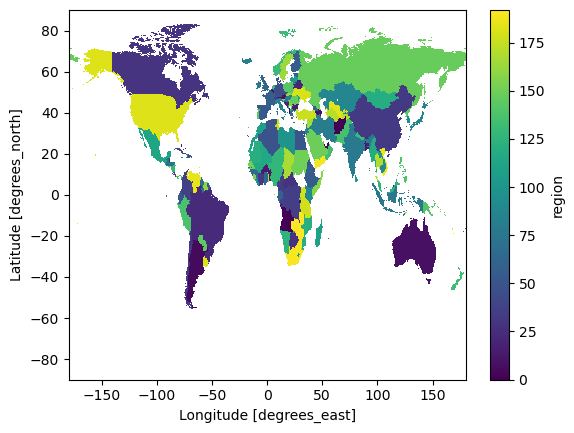

In [41]:
countries_mask.plot()

In [ ]:



# loop over countries as read in by worldbank data - Palestine and South Sudan are not in shapefile
for name in df_countries.index.values: 

    if name in gdf_country_borders['name'].values:
        # only keep countries that are resolved with mask (get rid of small countries)
        if da_population.where(countries_mask==countries_regions.map_keys(name), drop=True).size != 0:
            # get mask index and sum up masked population
            df_countries.loc[name,'population'] = da_population.where(countries_mask==countries_regions.map_keys(name), drop=True).sum().values
    

In [32]:
df_countries

,country,abbreviation,country_code,region,incomegroup,name,population
0,Afghanistan,AFG,3,South Asia,Low income,0,7.843547e+09
1,Albania,ALB,103,Europe & Central Asia,Upper middle income,1,3.289403e+08
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income,2,6.210228e+09
3,Andorra,AND,403,Europe & Central Asia,High income,3,NaN
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income,4,4.787205e+09
...,...,...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN,190,3.497172e+09
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income,191,1.150473e+10
192,Yemen,YEM,23003,Middle East & North Africa,Low income,192,5.625751e+09
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,193,3.537702e+09


In [33]:
# remove countries which are not found in country borders file
df_countries_filter = df_countries[~df_countries.loc[:, 'population'].isnull()]

df_countries_filter

,country,abbreviation,country_code,region,incomegroup,name,population
0,Afghanistan,AFG,3,South Asia,Low income,0,7.843547e+09
1,Albania,ALB,103,Europe & Central Asia,Upper middle income,1,3.289403e+08
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income,2,6.210228e+09
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income,4,4.787205e+09
6,Argentina,ARG,803,Latin America & Caribbean,Upper middle income,6,6.136918e+09
...,...,...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN,190,3.497172e+09
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income,191,1.150473e+10
192,Yemen,YEM,23003,Middle East & North Africa,Low income,192,5.625751e+09
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,193,3.537702e+09


In [72]:
df_countries

,country,abbreviation,country_code,region,incomegroup,name,population
0,Afghanistan,AFG,3,South Asia,Low income,0,7.843547e+09
1,Albania,ALB,103,Europe & Central Asia,Upper middle income,1,3.289403e+08
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income,2,6.210228e+09
3,Andorra,AND,403,Europe & Central Asia,High income,3,NaN
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income,4,4.787205e+09
...,...,...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN,190,3.497172e+09
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income,191,1.150473e+10
192,Yemen,YEM,23003,Middle East & North Africa,Low income,192,5.625751e+09
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,193,3.537702e+09


In [63]:
gdf_country_borders

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,ABBREV_LEN,TINY,HOMEPART,geometry,country,abbreviation,country_code,region,incomegroup,name
0,0,Admin-0 country,3.0,Afghanistan,AFG,0.0,2.0,Sovereign country,Afghanistan,AFG,...,4.0,-99.0,1.0,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",Afghanistan,AFG,3,South Asia,Low income,0
1,0,Admin-0 country,3.0,Angola,AGO,0.0,2.0,Sovereign country,Angola,AGO,...,4.0,-99.0,1.0,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Angola,AGO,503,Sub-Saharan Africa,Lower middle income,4
2,0,Admin-0 country,6.0,Albania,ALB,0.0,2.0,Sovereign country,Albania,ALB,...,4.0,-99.0,1.0,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Albania,ALB,103,Europe & Central Asia,Upper middle income,1
3,0,Admin-0 country,6.0,Andorra,AND,0.0,2.0,Sovereign country,Andorra,AND,...,4.0,5.0,1.0,"POLYGON ((1.70701 42.50278, 1.69750 42.49446, ...",Andorra,AND,403,Europe & Central Asia,High income,3
4,0,Admin-0 country,4.0,United Arab Emirates,ARE,0.0,2.0,Sovereign country,United Arab Emirates,ARE,...,6.0,-99.0,1.0,"MULTIPOLYGON (((53.86305 24.23469, 53.88860 24...",United Arab Emirates,ARE,21903,Middle East & North Africa,High income,184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,3,Admin-0 country,4.0,Samoa,WSM,0.0,2.0,Sovereign country,Samoa,WSM,...,5.0,-99.0,1.0,"MULTIPOLYGON (((-171.57002 -13.93816, -171.564...",Samoa,WSM,17903,East Asia & Pacific,Lower middle income,149
189,0,Admin-0 country,3.0,Yemen,YEM,0.0,2.0,Sovereign country,Yemen,YEM,...,4.0,-99.0,1.0,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Yemen,YEM,23003,Middle East & North Africa,Low income,192
190,0,Admin-0 country,2.0,South Africa,ZAF,0.0,2.0,Sovereign country,South Africa,ZAF,...,5.0,-99.0,1.0,"MULTIPOLYGON (((37.86378 -46.94085, 37.83644 -...",South Africa,ZAF,19303,Sub-Saharan Africa,Upper middle income,162
191,0,Admin-0 country,3.0,Zambia,ZMB,0.0,2.0,Sovereign country,Zambia,ZMB,...,6.0,-99.0,1.0,"POLYGON ((31.11984 -8.61663, 31.14102 -8.60619...",Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,193


In [64]:


# fix country borders dataframe for return
gdf_country_borders_filter = gdf_country_borders.set_index(gdf_country_borders.name).loc[:,['geometry','region']].reindex(df_countries_filter.index)

gdf_country_borders_filter

,geometry,region
0,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",South Asia
1,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia
2,"POLYGON ((8.60251 36.93951, 8.60566 36.91305, ...",Middle East & North Africa
4,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Sub-Saharan Africa
6,"MULTIPOLYGON (((-68.65412 -54.88624, -68.65414...",Latin America & Caribbean
...,...,...
190,"MULTIPOLYGON (((-61.39027 8.58058, -61.36986 8...",Latin America & Caribbean
191,"MULTIPOLYGON (((106.66871 8.75349, 106.66586 8...",East Asia & Pacific
192,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Middle East & North Africa
193,"POLYGON ((31.11984 -8.61663, 31.14102 -8.60619...",Sub-Saharan Africa


In [ ]:
df_countries[df_countries.loc[:, 'population'].isnull()]


# countries dropped bc of null population 

,country,abbreviation,country_code,region,incomegroup,name,population
3,Andorra,AND,403,Europe & Central Asia,High income,3,NaN
5,Antigua and Barbuda,ATG,703,Latin America & Caribbean,High income,5,NaN
12,Bahrain,BHR,1503,Middle East & North Africa,High income,12,NaN
14,Barbados,BRB,1703,Latin America & Caribbean,High income,14,NaN
48,Dominica,DMA,5503,Latin America & Caribbean,Upper middle income,48,NaN
67,Grenada,GRD,7903,Latin America & Caribbean,Upper middle income,67,NaN
100,Liechtenstein,LIE,11603,Europe & Central Asia,High income,100,NaN
106,Maldives,MDV,12403,South Asia,Upper middle income,106,NaN
108,Malta,MLT,12603,Middle East & North Africa,High income,108,NaN
109,Marshall Islands,MHL,12703,East Asia & Pacific,Upper middle income,109,NaN


### check what countries have been lost

With the shapefile and getting rid of countries that have zero population it seems there are 172 countries, 

possible reasons a) new population data b) initial filtering on ISIPEDIA countrymask in df_metadata


In [65]:

ver='pickles_S2S_v1'
dir_s2s = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/Source2Suffering'
d_countries_old = pk.load(open(os.path.join(dir_s2s,'data/{}/country/d_countries.pkl'.format(ver)), 'rb'))

In [67]:
d_countries = d_countries_old 

df_countries_old = d_countries['info_pop']
gdf_country_borders_old = d_countries['borders']
da_regions_old = df_countries_old['region'].unique()
da_population_old = d_countries['population_map']
df_birthyears_old = d_countries['birth_years'] # ROSA: in dem4cli this is None
df_life_expectancy_5_old = d_countries['life_expectancy_5']
da_cohort_size_old = d_countries['cohort_size']
countries_regions_old, countries_mask_old = d_countries['mask'] # ROSA: in dem4cli this is None

In [69]:
df_countries_old

,abbreviation,region,incomegroup,name,population
name,,,,,
Afghanistan,AFG,South Asia,Low income,Afghanistan,9.200959e+09
Angola,AGO,Sub-Saharan Africa,Lower middle income,Angola,4.175121e+09
Albania,ALB,Europe & Central Asia,Upper middle income,Albania,4.181980e+08
United Arab Emirates,ARE,Middle East & North Africa,High income,United Arab Emirates,6.241033e+08
Argentina,ARG,Latin America & Caribbean,High income,Argentina,6.610718e+09
...,...,...,...,...,...
Samoa,WSM,East Asia & Pacific,Upper middle income,Samoa,1.255803e+06
Yemen,YEM,Middle East & North Africa,Low income,Yemen,6.332028e+09
South Africa,ZAF,Sub-Saharan Africa,Upper middle income,South Africa,7.450973e+09


In [73]:
df_countries_filter

,country,abbreviation,country_code,region,incomegroup,name,population
0,Afghanistan,AFG,3,South Asia,Low income,0,7.843547e+09
1,Albania,ALB,103,Europe & Central Asia,Upper middle income,1,3.289403e+08
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income,2,6.210228e+09
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income,4,4.787205e+09
6,Argentina,ARG,803,Latin America & Caribbean,Upper middle income,6,6.136918e+09
...,...,...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN,190,3.497172e+09
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income,191,1.150473e+10
192,Yemen,YEM,23003,Middle East & North Africa,Low income,192,5.625751e+09
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,193,3.537702e+09


In [77]:
# elements in old but not in new
missing = df_countries_old[~df_countries_old["abbreviation"].isin(df_countries_filter["abbreviation"])]
missing

,abbreviation,region,incomegroup,name,population
name,,,,,
New Caledonia,NCL,East Asia & Pacific,High income,New Caledonia,1.497995e+07
Puerto Rico,PRI,Latin America & Caribbean,High income,Puerto Rico,3.828508e+08
French Polynesia,PYF,East Asia & Pacific,High income,French Polynesia,0.000000e+00
South Sudan,SDS,Sub-Saharan Africa,Low income,South Sudan,1.879990e+09
United States Virgin Islands,VIR,Latin America & Caribbean,High income,United States Virgin Islands,1.955049e+06


In [79]:
# check if they are missing in isipedia 

df_isimip_metadata = pd.read_json(filepath_isimip_countries_meta).replace(-9999, np.nan)
df_isimip_metadata

,country,country_code,country_iso3,rank,HDI_Human_development_index_HDIg_value,IHDI_Inequality_adjusted_HDI_geom_value,MPI_2019_Multidimensional_poverty_index_revised,GII_Gender_Inequality_Index_value,GDI_Gender_Development_Index
0,Afghanistan,3,AFG,170.0,0.496,NaN,0.272,0.575,0.723
1,Albania,103,ALB,69.0,0.791,0.705,0.003,0.234,0.971
2,Algeria,203,DZA,82.0,0.759,0.604,0.008,0.443,0.865
3,Andorra,403,AND,36.0,0.857,NaN,NaN,NaN,NaN
4,Angola,503,AGO,149.0,0.574,0.392,0.282,0.578,0.902
...,...,...,...,...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),22503,VEN,96.0,0.726,0.600,NaN,0.458,1.013
191,Viet Nam,22603,VNM,118.0,0.693,0.580,0.019,0.314,1.003
192,Yemen,23003,YEM,177.0,0.463,0.316,0.241,0.834,0.458
193,Zambia,23103,ZMB,143.0,0.591,0.394,0.261,0.540,0.948


In [80]:
# countries in old that arent in isipedia

df_countries_old[~df_countries_old["abbreviation"].isin(df_isimip_metadata["country_iso3"])]

,abbreviation,region,incomegroup,name,population
name,,,,,
New Caledonia,NCL,East Asia & Pacific,High income,New Caledonia,1.497995e+07
Puerto Rico,PRI,Latin America & Caribbean,High income,Puerto Rico,3.828508e+08
French Polynesia,PYF,East Asia & Pacific,High income,French Polynesia,0.000000e+00
South Sudan,SDS,Sub-Saharan Africa,Low income,South Sudan,1.879990e+09
United States Virgin Islands,VIR,Latin America & Caribbean,High income,United States Virgin Islands,1.955049e+06


In [82]:
df_wb_countries = pd.read_excel(filepath_world_bank_meta, sheet_name=0)


### lost due to isipedia filtering : fix it by filtering only based on world bank

try without isipedia filtering

In [3]:
# open world bank categorization: 218 countries total 
df_metadata = pd.read_excel(filepath_world_bank_meta, sheet_name=0)
# get rid of regions 
df_metadata = df_metadata[~df_metadata['Region'].isna()]
# rename
keep_cols =['Economy', 'Code', 'Region', 'Income group']
d_rename={'Economy':'country','Code':'abbreviation', 'Region':'region', 'Income group': 'incomegroup'}
df_metadata = df_metadata[keep_cols].rename(columns=d_rename) 

df_metadata # world bank : 218 countries

,country,abbreviation,region,incomegroup
0,Afghanistan,AFG,South Asia,Low income
1,Albania,ALB,Europe & Central Asia,Upper middle income
2,Algeria,DZA,Middle East & North Africa,Upper middle income
3,American Samoa,ASM,East Asia & Pacific,High income
4,Andorra,AND,Europe & Central Asia,High income
...,...,...,...,...
213,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income
214,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income
215,"Yemen, Rep.",YEM,Middle East & North Africa,Low income
216,Zambia,ZMB,Sub-Saharan Africa,Lower middle income


In [4]:
df_metadata['name'] = df_metadata['country']
df_countries = df_metadata.set_index('name', drop=False)
df_countries


,country,abbreviation,region,incomegroup,name
name,,,,,
Afghanistan,Afghanistan,AFG,South Asia,Low income,Afghanistan
Albania,Albania,ALB,Europe & Central Asia,Upper middle income,Albania
Algeria,Algeria,DZA,Middle East & North Africa,Upper middle income,Algeria
American Samoa,American Samoa,ASM,East Asia & Pacific,High income,American Samoa
Andorra,Andorra,AND,Europe & Central Asia,High income,Andorra
...,...,...,...,...,...
Virgin Islands (U.S.),Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,Virgin Islands (U.S.)
West Bank and Gaza,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,West Bank and Gaza
"Yemen, Rep.","Yemen, Rep.",YEM,Middle East & North Africa,Low income,"Yemen, Rep."


In [5]:
gdf_country_borders_raw = gpd.read_file(filepath_countrymask)

In [260]:
# gdf_country_borders_raw # len:255

In [6]:


#rename from incorrect in shapefile to correct in Worldbank. 
d_rename={'KOS':'XKX', 'SDS':'SSD', 'PSX':'PSE'}

gdf_country_borders = gdf_country_borders_raw.replace({"ADM0_A3": d_rename})

gdf_country_borders = gdf_country_borders.merge(
    df_countries, 
    how='inner', # only in both world bank and gdf : 217 countries 
    left_on='ADM0_A3', 
    right_on='abbreviation'
)

gdf_country_borders

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,geometry,country,abbreviation,region,incomegroup,name
0,3,Admin-0 country,5.0,Netherlands,NL1,1.0,2.0,Country,Aruba,ABW,...,5.0,5.0,4.0,-99.0,"POLYGON ((-69.99694 12.57758, -69.93639 12.531...",Aruba,ABW,Latin America & Caribbean,High income,Aruba
1,0,Admin-0 country,3.0,Afghanistan,AFG,0.0,2.0,Sovereign country,Afghanistan,AFG,...,11.0,4.0,-99.0,1.0,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",Afghanistan,AFG,South Asia,Low income,Afghanistan
2,0,Admin-0 country,3.0,Angola,AGO,0.0,2.0,Sovereign country,Angola,AGO,...,6.0,4.0,-99.0,1.0,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Angola,AGO,Sub-Saharan Africa,Lower middle income,Angola
3,0,Admin-0 country,6.0,Albania,ALB,0.0,2.0,Sovereign country,Albania,ALB,...,7.0,4.0,-99.0,1.0,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Albania,ALB,Europe & Central Asia,Upper middle income,Albania
4,0,Admin-0 country,6.0,Andorra,AND,0.0,2.0,Sovereign country,Andorra,AND,...,7.0,4.0,5.0,1.0,"POLYGON ((1.70701 42.50278, 1.69750 42.49446, ...",Andorra,AND,Europe & Central Asia,High income,Andorra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,3,Admin-0 country,4.0,Samoa,WSM,0.0,2.0,Sovereign country,Samoa,WSM,...,5.0,5.0,-99.0,1.0,"MULTIPOLYGON (((-171.57002 -13.93816, -171.564...",Samoa,WSM,East Asia & Pacific,Lower middle income,Samoa
213,0,Admin-0 country,3.0,Yemen,YEM,0.0,2.0,Sovereign country,Yemen,YEM,...,5.0,4.0,-99.0,1.0,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...","Yemen, Rep.",YEM,Middle East & North Africa,Low income,"Yemen, Rep."
214,0,Admin-0 country,2.0,South Africa,ZAF,0.0,2.0,Sovereign country,South Africa,ZAF,...,12.0,5.0,-99.0,1.0,"MULTIPOLYGON (((37.86378 -46.94085, 37.83644 -...",South Africa,ZAF,Sub-Saharan Africa,Upper middle income,South Africa
215,0,Admin-0 country,3.0,Zambia,ZMB,0.0,2.0,Sovereign country,Zambia,ZMB,...,6.0,6.0,-99.0,1.0,"POLYGON ((31.11984 -8.61663, 31.14102 -8.60619...",Zambia,ZMB,Sub-Saharan Africa,Lower middle income,Zambia


In [9]:
# create regionmask regions object 
countries_regions = regionmask.from_geopandas(
    gdf_country_borders, 
    names='name', 
    abbrevs="abbreviation", 
    name="country"
)

countries_mask = countries_regions.mask(da_population.lon, da_population.lat)


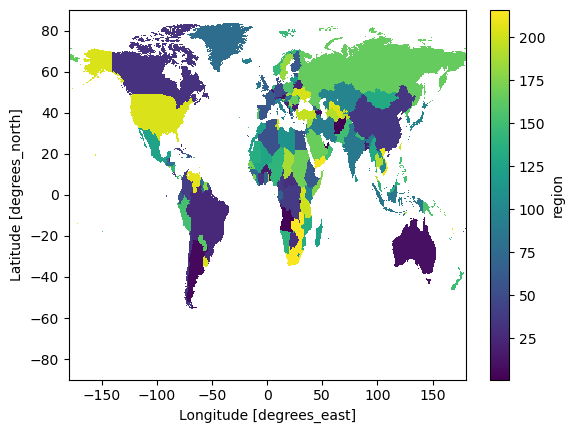

In [10]:
countries_mask.plot()

In [11]:
countries_regions

<regionmask.Regions 'country'>
overlap:  None

Regions:
  0 ABW        Aruba
  1 AFG  Afghanistan
  2 AGO       Angola
  3 ALB      Albania
  4 AND      Andorra
 ..  ..          ...
212 WSM        Samoa
213 YEM  Yemen, Rep.
214 ZAF South Africa
215 ZMB       Zambia
216 ZWE     Zimbabwe

[217 regions]

In [12]:
countries_mask

<xarray.DataArray 'mask' (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  region
    flag_values:    [  1   2   3   5   6   7  10  11  12  13  14  15  16  17 ...
    flag_meanings:  AFG AGO ALB ARE ARG ARM AUS AUT AZE BDI BEL BEN BFA BGD B...

In [13]:
countries_regions.map_keys

<bound method Regions.map_keys of <regionmask.Regions 'country'>
overlap:  None

Regions:
  0 ABW        Aruba
  1 AFG  Afghanistan
  2 AGO       Angola
  3 ALB      Albania
  4 AND      Andorra
 ..  ..          ...
212 WSM        Samoa
213 YEM  Yemen, Rep.
214 ZAF South Africa
215 ZMB       Zambia
216 ZWE     Zimbabwe

[217 regions]>

In [14]:


# loop over countries as read in by worldbank data 
for name in df_countries.index.values: 
    # if it is also in the geodataframe from the shapefile
    if name in gdf_country_borders['name'].values:
        # only keep countries that are resolved with mask (get rid of small countries)
        if da_population.where(countries_mask==countries_regions.map_keys(name), drop=True).size != 0:
            # get mask index and sum up masked population
            df_countries.loc[name,'population'] = da_population.where(countries_mask==countries_regions.map_keys(name), drop=True).sum().values
    

In [15]:
df_countries

,country,abbreviation,region,incomegroup,name,population
name,,,,,,
Afghanistan,Afghanistan,AFG,South Asia,Low income,Afghanistan,7.843547e+09
Albania,Albania,ALB,Europe & Central Asia,Upper middle income,Albania,3.289403e+08
Algeria,Algeria,DZA,Middle East & North Africa,Upper middle income,Algeria,6.210228e+09
American Samoa,American Samoa,ASM,East Asia & Pacific,High income,American Samoa,NaN
Andorra,Andorra,AND,Europe & Central Asia,High income,Andorra,NaN
...,...,...,...,...,...,...
Virgin Islands (U.S.),Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,Virgin Islands (U.S.),6.179032e+06
West Bank and Gaza,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,West Bank and Gaza,9.166136e+08
"Yemen, Rep.","Yemen, Rep.",YEM,Middle East & North Africa,Low income,"Yemen, Rep.",5.625751e+09


In [16]:
# remove countries which are not resolved with mask (have zero population)
df_countries_filter = df_countries[~df_countries.loc[:, 'population'].isnull()]

df_countries_filter

,country,abbreviation,region,incomegroup,name,population
name,,,,,,
Afghanistan,Afghanistan,AFG,South Asia,Low income,Afghanistan,7.843547e+09
Albania,Albania,ALB,Europe & Central Asia,Upper middle income,Albania,3.289403e+08
Algeria,Algeria,DZA,Middle East & North Africa,Upper middle income,Algeria,6.210228e+09
Angola,Angola,AGO,Sub-Saharan Africa,Lower middle income,Angola,4.787205e+09
Argentina,Argentina,ARG,Latin America & Caribbean,Upper middle income,Argentina,6.136918e+09
...,...,...,...,...,...,...
Virgin Islands (U.S.),Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,Virgin Islands (U.S.),6.179032e+06
West Bank and Gaza,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,West Bank and Gaza,9.166136e+08
"Yemen, Rep.","Yemen, Rep.",YEM,Middle East & North Africa,Low income,"Yemen, Rep.",5.625751e+09


In [17]:


# fix country borders dataframe for return
gdf_country_borders_filter = gdf_country_borders.set_index(gdf_country_borders.name).loc[:,['geometry','region', 'ADM0_A3']].rename(columns={'ADM0_A3':'abbreviation'}).reindex(df_countries_filter.index)

gdf_country_borders_filter

# 183 countries 

,geometry,region,abbreviation
name,,,
Afghanistan,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",South Asia,AFG
Albania,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60251 36.93951, 8.60566 36.91305, ...",Middle East & North Africa,DZA
Angola,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Sub-Saharan Africa,AGO
Argentina,"MULTIPOLYGON (((-68.65412 -54.88624, -68.65414...",Latin America & Caribbean,ARG
...,...,...,...
Virgin Islands (U.S.),"MULTIPOLYGON (((-64.73078 17.76529, -64.70971 ...",Latin America & Caribbean,VIR
West Bank and Gaza,"MULTIPOLYGON (((34.26440 31.22419, 34.24835 31...",Middle East & North Africa,PSE
"Yemen, Rep.","MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Middle East & North Africa,YEM


In [283]:
df_countries[df_countries.loc[:, 'population'].isnull()]


# countries dropped bc of null population or not in shapefile

# maybe with a different shapefile this could be better ? 

,country,abbreviation,region,incomegroup,name,population
name,,,,,,
American Samoa,American Samoa,ASM,East Asia & Pacific,High income,American Samoa,NaN
Andorra,Andorra,AND,Europe & Central Asia,High income,Andorra,NaN
Antigua and Barbuda,Antigua and Barbuda,ATG,Latin America & Caribbean,High income,Antigua and Barbuda,NaN
Aruba,Aruba,ABW,Latin America & Caribbean,High income,Aruba,NaN
Bahrain,Bahrain,BHR,Middle East & North Africa,High income,Bahrain,NaN
Barbados,Barbados,BRB,Latin America & Caribbean,High income,Barbados,NaN
Bermuda,Bermuda,BMU,North America,High income,Bermuda,NaN
British Virgin Islands,British Virgin Islands,VGB,Latin America & Caribbean,High income,British Virgin Islands,NaN
Channel Islands,Channel Islands,CHI,Europe & Central Asia,High income,Channel Islands,NaN


In [284]:
## what are additional countries wrt old d_countries 

# note, havent yet filtered based on availability of cohort sizes, life expectancy etc. 

# elements in old but not in new
missing = df_countries_old[~df_countries_old["abbreviation"].isin(df_countries_filter["abbreviation"])]
missing

# correct abbreviation is SSD not SDS - where did Luke get this from ? 

,abbreviation,region,incomegroup,name,population
name,,,,,
South Sudan,SDS,Sub-Saharan Africa,Low income,South Sudan,1.879990e+09


In [285]:
# elements in new but not in old 
# palestine, south sudan and kosovo were incorrectly abbreviated
# the others not sure why i got them back? 

missing = df_countries_filter[~df_countries_filter["abbreviation"].isin(df_countries_old["abbreviation"])]
missing

,country,abbreviation,region,incomegroup,name,population
name,,,,,,
Cayman Islands,Cayman Islands,CYM,Latin America & Caribbean,High income,Cayman Islands,1.639615e+05
Faroe Islands,Faroe Islands,FRO,Europe & Central Asia,High income,Faroe Islands,5.129665e+06
Greenland,Greenland,GRL,Europe & Central Asia,High income,Greenland,1.304634e+06
Kosovo,Kosovo,XKX,Europe & Central Asia,Upper middle income,Kosovo,3.027495e+08
South Sudan,South Sudan,SSD,Sub-Saharan Africa,Low income,South Sudan,1.431551e+09
"Taiwan, China","Taiwan, China",TWN,East Asia & Pacific,High income,"Taiwan, China",1.840079e+09
West Bank and Gaza,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,West Bank and Gaza,9.166136e+08


In [286]:
# countries in world bank but not in shapefile 

missing = df_metadata[~df_metadata["abbreviation"].isin(gdf_country_borders["abbreviation"])]
missing

# Channel islands are in shapefile actually but as Jersey and Guernsey - I am ignoring these for now

,country,abbreviation,region,incomegroup,name
39,Channel Islands,CHI,Europe & Central Asia,High income,Channel Islands


In [287]:
# countries in shapefile but not in worldbank - mostly dependencies, overseas terrritories etc. 

missing = gdf_country_borders_raw[~gdf_country_borders_raw["ADM0_A3"].isin(df_metadata["abbreviation"])]
missing

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,geometry
3,3,Admin-0 country,6.0,United Kingdom,GB1,1.0,2.0,Dependency,Anguilla,AIA,...,North America,Americas,Caribbean,Latin America & Caribbean,8.0,8.0,4.0,-99.0,-99.0,"MULTIPOLYGON (((-63.03767 18.21296, -63.09952 ..."
5,3,Admin-0 country,6.0,Finland,FI1,1.0,2.0,Country,Aland,ALD,...,Europe,Europe,Northern Europe,Europe & Central Asia,5.0,13.0,5.0,5.0,-99.0,"MULTIPOLYGON (((20.92018 59.90925, 20.91236 59..."
11,0,Admin-0 country,4.0,Antarctica,ATA,0.0,2.0,Indeterminate,Antarctica,ATA,...,Antarctica,Antarctica,Antarctica,Antarctica,10.0,10.0,4.0,-99.0,1.0,"MULTIPOLYGON (((-162.40905 -82.89642, -162.339..."
12,6,Admin-0 country,5.0,Australia,AU1,1.0,2.0,Dependency,Ashmore and Cartier Islands,ATC,...,Oceania,Oceania,Australia and New Zealand,East Asia & Pacific,23.0,27.0,7.0,-99.0,-99.0,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."
13,3,Admin-0 country,6.0,France,FR1,1.0,2.0,Dependency,French Southern and Antarctic Lands,ATF,...,Seven seas (open ocean),Seven seas (open ocean),Seven seas (open ocean),Sub-Saharan Africa,22.0,35.0,10.0,2.0,-99.0,"MULTIPOLYGON (((70.01612 -49.56422, 70.00709 -..."
27,6,Admin-0 country,8.0,Bajo Nuevo Bank (Petrel Is.),BJN,0.0,2.0,Indeterminate,Bajo Nuevo Bank (Petrel Is.),BJN,...,North America,Americas,Caribbean,Latin America & Caribbean,28.0,32.0,0.0,-99.0,1.0,"POLYGON ((-79.98929 15.79495, -79.98782 15.796..."
28,6,Admin-0 country,6.0,France,FR1,1.0,2.0,Dependency,Saint Barthelemy,BLM,...,North America,Americas,Caribbean,Latin America & Caribbean,13.0,16.0,6.0,4.0,-99.0,"POLYGON ((-62.83886 17.88198, -62.85094 17.890..."
44,6,Admin-0 country,5.0,France,FR1,1.0,2.0,Dependency,Clipperton Island,CLP,...,Seven seas (open ocean),Americas,Central America,Latin America & Caribbean,13.0,17.0,7.0,-99.0,-99.0,"POLYGON ((-109.21203 10.30268, -109.21036 10.2..."
46,1,Admin-0 country,9.0,Cyprus No Mans Area,CNM,0.0,2.0,Indeterminate,Cyprus No Mans Area,CNM,...,Asia,Asia,Western Asia,Europe & Central Asia,23.0,23.0,0.0,-99.0,1.0,"MULTIPOLYGON (((33.92540 35.06277, 33.94111 35..."
49,5,Admin-0 country,4.0,New Zealand,NZ1,1.0,2.0,Dependency,Cook Islands,COK,...,Oceania,Oceania,Polynesia,East Asia & Pacific,8.0,12.0,8.0,3.0,-99.0,"MULTIPOLYGON (((-157.91511 -21.93768, -157.927..."


In [18]:
# crop with bbox 

gdf_country_borders_filter

,geometry,region,abbreviation
name,,,
Afghanistan,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",South Asia,AFG
Albania,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60251 36.93951, 8.60566 36.91305, ...",Middle East & North Africa,DZA
Angola,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Sub-Saharan Africa,AGO
Argentina,"MULTIPOLYGON (((-68.65412 -54.88624, -68.65414...",Latin America & Caribbean,ARG
...,...,...,...
Virgin Islands (U.S.),"MULTIPOLYGON (((-64.73078 17.76529, -64.70971 ...",Latin America & Caribbean,VIR
West Bank and Gaza,"MULTIPOLYGON (((34.26440 31.22419, 34.24835 31...",Middle East & North Africa,PSE
"Yemen, Rep.","MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Middle East & North Africa,YEM


In [20]:
from shapely.geometry import box

bbox_europe = [ 31.99,  71.09, -14.96,  34.94]

miny, maxy, minx, maxx = bbox_europe

# define bounding box (minx, miny, maxx, maxy)
bbox = box(minx, miny, maxx, maxy)

# keep only geometries fully inside bbox
gdf_inside = gdf_country_borders_filter[gdf_country_borders_filter.within(bbox)]

In [21]:
gdf_inside

,geometry,region,abbreviation
name,,,
Albania,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia,ALB
Austria,"POLYGON ((15.16179 48.93722, 15.23807 48.95076...",Europe & Central Asia,AUT
Belarus,"POLYGON ((28.14891 56.14241, 28.16911 56.12526...",Europe & Central Asia,BLR
Belgium,"POLYGON ((4.81545 51.43107, 4.82268 51.41368, ...",Europe & Central Asia,BEL
Bosnia and Herzegovina,"POLYGON ((16.94153 45.24122, 16.94732 45.23569...",Europe & Central Asia,BIH
Bulgaria,"POLYGON ((22.91956 43.83422, 23.05255 43.84282...",Europe & Central Asia,BGR
Croatia,"MULTIPOLYGON (((16.93393 42.77094, 16.93637 42...",Europe & Central Asia,HRV
Cyprus,"MULTIPOLYGON (((33.77399 34.98867, 33.77792 34...",Europe & Central Asia,CYP
Czechia,"POLYGON ((14.39781 51.01311, 14.42582 51.02094...",Europe & Central Asia,CZE


In [22]:
len(gdf_inside)

33

<Axes: >

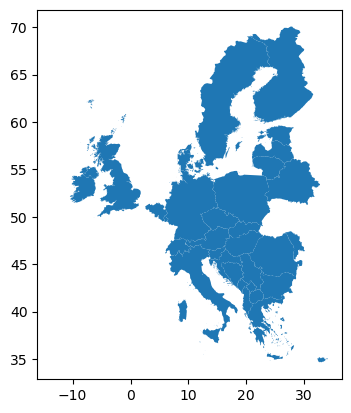

In [26]:
gdf_inside.plot()

In [23]:
gdf_cropped = gpd.clip(gdf_country_borders_filter, bbox)


In [24]:
gdf_cropped

,geometry,region,abbreviation
name,,,
Israel,"POLYGON ((34.74334 32.03986, 34.74399 32.04462...",Middle East & North Africa,ISR
Cyprus,"MULTIPOLYGON (((33.77792 34.98469, 33.78257 34...",Europe & Central Asia,CYP
Türkiye,"MULTIPOLYGON (((26.04623 39.84406, 26.05112 39...",Europe & Central Asia,TUR
Ukraine,"MULTIPOLYGON (((29.73097 45.59138, 29.78126 45...",Europe & Central Asia,UKR
Poland,"POLYGON ((19.37721 54.37763, 19.45997 54.40103...",Europe & Central Asia,POL
Belarus,"POLYGON ((28.16911 56.12526, 28.23846 56.08262...",Europe & Central Asia,BLR
Lithuania,"MULTIPOLYGON (((20.98943 55.27312, 20.92457 55...",Europe & Central Asia,LTU
Latvia,"POLYGON ((25.33988 58.03258, 25.34639 58.03444...",Europe & Central Asia,LVA
Estonia,"MULTIPOLYGON (((23.25025 57.78437, 23.22950 57...",Europe & Central Asia,EST


In [25]:
len(gdf_cropped)

47

<Axes: >

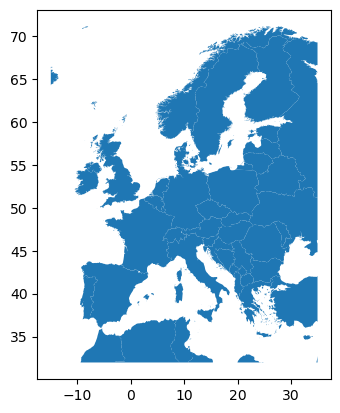

In [27]:
gdf_cropped.plot()

### test function

In [28]:
flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [29]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]

In [30]:
da_population = load_population()

opening compass - historical
opening compass - ssp2


In [31]:
df_metadata = load_country_metadata(filepath_world_bank = filepath_world_bank_meta,)

In [32]:
# global

gdf_country_borders, countries_regions, countries_mask, df_countries = load_countrymask(
    filepath_countrymask=filepath_countrymask,
    data_source_countrymask=flags['countrymask'],
    df_metadata=df_metadata,       # make sure this is only WB not also filtered on isipedia! 
    da_population=da_population,
    fillcoast=False, # True if you want to preprocess and fill coastal pixels to not lose coastal pops (done already in preprocessed files)
    fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
    bbox=None,)

In [33]:
gdf_country_borders

,geometry,region,abbreviation
name,,,
Afghanistan,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",South Asia,AFG
Albania,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60251 36.93951, 8.60566 36.91305, ...",Middle East & North Africa,DZA
Angola,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Sub-Saharan Africa,AGO
Argentina,"MULTIPOLYGON (((-68.65412 -54.88624, -68.65414...",Latin America & Caribbean,ARG
...,...,...,...
Virgin Islands (U.S.),"MULTIPOLYGON (((-64.73078 17.76529, -64.70971 ...",Latin America & Caribbean,VIR
West Bank and Gaza,"MULTIPOLYGON (((34.26440 31.22419, 34.24835 31...",Middle East & North Africa,PSE
"Yemen, Rep.","MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Middle East & North Africa,YEM


In [34]:
df_countries

,country,abbreviation,region,incomegroup,name,population
name,,,,,,
Afghanistan,Afghanistan,AFG,South Asia,Low income,Afghanistan,7.843547e+09
Albania,Albania,ALB,Europe & Central Asia,Upper middle income,Albania,3.289403e+08
Algeria,Algeria,DZA,Middle East & North Africa,Upper middle income,Algeria,6.210228e+09
Angola,Angola,AGO,Sub-Saharan Africa,Lower middle income,Angola,4.787205e+09
Argentina,Argentina,ARG,Latin America & Caribbean,Upper middle income,Argentina,6.136918e+09
...,...,...,...,...,...,...
Virgin Islands (U.S.),Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,Virgin Islands (U.S.),6.179032e+06
West Bank and Gaza,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,West Bank and Gaza,9.166136e+08
"Yemen, Rep.","Yemen, Rep.",YEM,Middle East & North Africa,Low income,"Yemen, Rep.",5.625751e+09


In [35]:
countries_regions

<regionmask.Regions 'country'>
overlap:  None

Regions:
  0 ABW        Aruba
  1 AFG  Afghanistan
  2 AGO       Angola
  3 ALB      Albania
  4 AND      Andorra
 ..  ..          ...
212 WSM        Samoa
213 YEM  Yemen, Rep.
214 ZAF South Africa
215 ZMB       Zambia
216 ZWE     Zimbabwe

[217 regions]

In [10]:
countries_mask

<xarray.DataArray 'mask' (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  region
    flag_values:    [  1   2   3   5   6   7  10  11  12  13  14  15  16  17 ...
    flag_meanings:  AFG AGO ALB ARE ARG ARM AUS AUT AZE BDI BEL BEN BFA BGD B...

In [11]:
len(np.unique(countries_mask.values[~np.isnan(countries_mask.values)]))

183

In [7]:
gdf_country_borders_europe, countries_regions_eu, countries_mask_eu, df_countries_eu = load_countrymask(
    filepath_countrymask=filepath_countrymask,
    data_source_countrymask=flags['countrymask'],
    df_metadata=df_metadata,       # make sure this is only WB not also filtered on isipedia! 
    da_population=da_population,
    fillcoast=False, # True if you want to preprocess and fill coastal pixels to not lose coastal pops (done already in preprocessed files)
    fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
    bbox=bbox_europe,)

<Axes: >

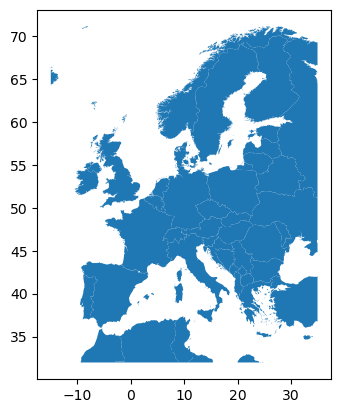

In [8]:
gdf_country_borders_europe.plot()

In [9]:
len(gdf_country_borders_europe)

46

In [10]:
gdf_country_borders_europe.index.nunique() 

46

In [11]:
countries_regions_eu

<regionmask.Regions 'country'>
overlap:  None

Regions:
  3 ALB  Albania
  4 AND  Andorra
 11 AUT  Austria
 14 BEL  Belgium
 18 BGR Bulgaria
 ..  ..      ...
181 SVN Slovenia
182 SWE   Sweden
196 TUN  Tunisia
197 TUR  Türkiye
202 UKR  Ukraine

[54 regions]

In [12]:
len(countries_regions_eu)

54

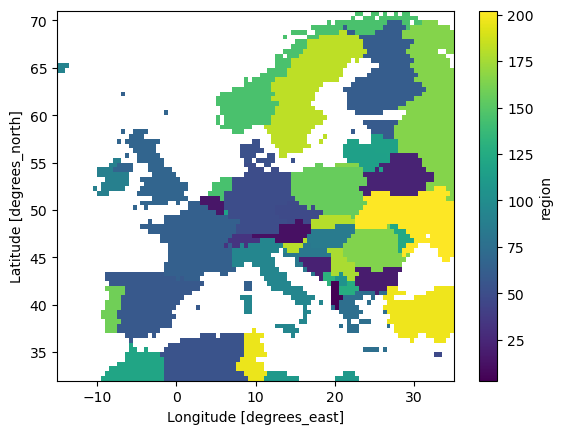

In [13]:
countries_mask_eu.plot()

In [14]:
len(np.unique(countries_mask_eu.values[~np.isnan(countries_mask_eu.values)]))

46

In [15]:
len(gdf_country_borders_europe)

46

### try with 0.1 deg

In [16]:
flags

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [23]:
flags['pop_resolution'] = 0.1
dir_population = '/data/brussel/vo/000/bvo00012/data/dataset/COMPASS/v2/population_count/'+float_to_str(flags['pop_resolution'])+'deg' # make a symlink in dem4cli? 

da_population = load_population(dir_population=dir_population)

gdf_country_borders_europe, countries_regions_eu, countries_mask_eu, df_countries_eu = load_countrymask(
    filepath_countrymask=filepath_countrymask,
    data_source_countrymask=flags['countrymask'],
    df_metadata=df_metadata,       # make sure this is only WB not also filtered on isipedia! 
    da_population=da_population,
    fillcoast=False, # True if you want to preprocess and fill coastal pixels to not lose coastal pops (done already in preprocessed files)
    fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
    bbox=bbox_europe,)

opening compass - historical
opening compass - ssp2


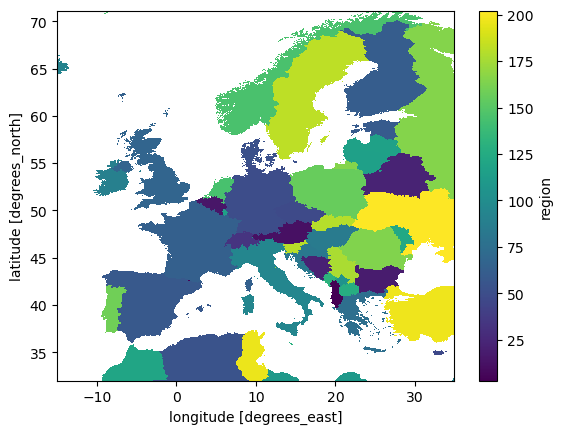

In [ ]:
countries_mask_eu.plot() # at 0.1 deg resolution 

In [27]:
gdf_country_borders_europe.loc[list(df_countries_eu.index)]

,geometry,region,abbreviation
name,,,
Albania,"POLYGON ((19.74601 42.57993, 19.74136 42.57441...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60566 36.91305, 8.60483 36.90098, ...",Middle East & North Africa,DZA
Andorra,"POLYGON ((1.69750 42.49446, 1.68634 42.49061, ...",Europe & Central Asia,AND
Austria,"POLYGON ((15.23807 48.95076, 15.24323 48.95293...",Europe & Central Asia,AUT
Belarus,"POLYGON ((28.16911 56.12526, 28.23846 56.08262...",Europe & Central Asia,BLR
Belgium,"POLYGON ((4.82268 51.41368, 4.77907 51.42642, ...",Europe & Central Asia,BEL
Bosnia and Herzegovina,"POLYGON ((16.94732 45.23569, 16.96799 45.23729...",Europe & Central Asia,BIH
Bulgaria,"POLYGON ((23.05255 43.84282, 23.13185 43.84794...",Europe & Central Asia,BGR
Croatia,"MULTIPOLYGON (((16.93637 42.75552, 16.92465 42...",Europe & Central Asia,HRV


In [25]:
df_countries_eu

,country,abbreviation,region,incomegroup,name,population
name,,,,,,
Albania,Albania,ALB,Europe & Central Asia,Upper middle income,Albania,3.338995e+08
Algeria,Algeria,DZA,Middle East & North Africa,Upper middle income,Algeria,5.949914e+09
Andorra,Andorra,AND,Europe & Central Asia,High income,Andorra,8.706433e+06
Austria,Austria,AUT,Europe & Central Asia,High income,Austria,1.295816e+09
Belarus,Belarus,BLR,Europe & Central Asia,Upper middle income,Belarus,1.299609e+09
Belgium,Belgium,BEL,Europe & Central Asia,High income,Belgium,1.704769e+09
Bosnia and Herzegovina,Bosnia and Herzegovina,BIH,Europe & Central Asia,Upper middle income,Bosnia and Herzegovina,4.585605e+08
Bulgaria,Bulgaria,BGR,Europe & Central Asia,High income,Bulgaria,9.957953e+08
Croatia,Croatia,HRV,Europe & Central Asia,High income,Croatia,5.265064e+08


### 2) try with all_touched - later maybe

In [51]:
import rasterio

def make_mask(shp, raster, all_touched=True):
    # detect coordinate names
    lat_name = "lat" if "lat" in raster.dims else "latitude"
    lon_name = "lon" if "lon" in raster.dims else "longitude"

    # ensure CRS
    geom = shp.to_crs(epsg=4326).geometry

    # get transform
    transform = raster.rio.transform()

    # build mask
    mask_array = rasterio.features.geometry_mask(
        geom,
        out_shape=(raster.sizes[lat_name], raster.sizes[lon_name]),
        transform=transform,
        all_touched=all_touched,
        invert=True
    )

    # wrap as DataArray with correct dims + coords
    mask_xr = xr.DataArray(
        mask_array,
        coords={lat_name: raster[lat_name], lon_name: raster[lon_name]},
        dims=[lat_name, lon_name]
    )

    return mask_xr

In [60]:
def make_mask_sublevels(shp, raster, colname='ADM0_A3', all_touched=True):
    # detect coordinate names
    lat_name = "lat" if "lat" in raster.dims else "latitude"
    lon_name = "lon" if "lon" in raster.dims else "longitude"

    # ensure CRS
    geom = shp.to_crs(epsg=4326).geometry

    # sizes
    lat_size, lon_size = raster.sizes[lat_name], raster.sizes[lon_name]
    mask_array = np.zeros((len(geom), lat_size, lon_size), dtype=bool)

    # get transform
    transform = raster.rio.transform()

    # loop over polygons
    for i, polygon in enumerate(geom):
        mask_array[i] = rasterio.features.geometry_mask(
            [polygon], 
            out_shape=(lat_size, lon_size),
            transform=transform,
            all_touched=all_touched,
            invert=True
        )

    # wrap as DataArray
    mask_xr = xr.DataArray(
        mask_array,
        coords={
            "ID": shp[colname].values,
            lat_name: raster[lat_name],
            lon_name: raster[lon_name]
        },
        dims=["ID", lat_name, lon_name]
    )

    return mask_xr

In [52]:
shp =  gpd.read_file(filepath_countrymask)

In [55]:
shp

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,geometry
0,3,Admin-0 country,5.0,Netherlands,NL1,1.0,2.0,Country,Aruba,ABW,...,North America,Americas,Caribbean,Latin America & Caribbean,5.0,5.0,5.0,4.0,-99.0,"POLYGON ((-69.99694 12.57758, -69.93639 12.531..."
1,0,Admin-0 country,3.0,Afghanistan,AFG,0.0,2.0,Sovereign country,Afghanistan,AFG,...,Asia,Asia,Southern Asia,South Asia,11.0,11.0,4.0,-99.0,1.0,"POLYGON ((71.04980 38.40866, 71.05714 38.40903..."
2,0,Admin-0 country,3.0,Angola,AGO,0.0,2.0,Sovereign country,Angola,AGO,...,Africa,Africa,Middle Africa,Sub-Saharan Africa,6.0,6.0,4.0,-99.0,1.0,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -..."
3,3,Admin-0 country,6.0,United Kingdom,GB1,1.0,2.0,Dependency,Anguilla,AIA,...,North America,Americas,Caribbean,Latin America & Caribbean,8.0,8.0,4.0,-99.0,-99.0,"MULTIPOLYGON (((-63.03767 18.21296, -63.09952 ..."
4,0,Admin-0 country,6.0,Albania,ALB,0.0,2.0,Sovereign country,Albania,ALB,...,Europe,Europe,Southern Europe,Europe & Central Asia,7.0,7.0,4.0,-99.0,1.0,"POLYGON ((19.74777 42.57890, 19.74601 42.57993..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,3,Admin-0 country,4.0,Samoa,WSM,0.0,2.0,Sovereign country,Samoa,WSM,...,Oceania,Oceania,Polynesia,East Asia & Pacific,5.0,5.0,5.0,-99.0,1.0,"MULTIPOLYGON (((-171.57002 -13.93816, -171.564..."
251,0,Admin-0 country,3.0,Yemen,YEM,0.0,2.0,Sovereign country,Yemen,YEM,...,Asia,Asia,Western Asia,Middle East & North Africa,5.0,5.0,4.0,-99.0,1.0,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12..."
252,0,Admin-0 country,2.0,South Africa,ZAF,0.0,2.0,Sovereign country,South Africa,ZAF,...,Africa,Africa,Southern Africa,Sub-Saharan Africa,12.0,12.0,5.0,-99.0,1.0,"MULTIPOLYGON (((37.86378 -46.94085, 37.83644 -..."
253,0,Admin-0 country,3.0,Zambia,ZMB,0.0,2.0,Sovereign country,Zambia,ZMB,...,Africa,Africa,Eastern Africa,Sub-Saharan Africa,6.0,6.0,6.0,-99.0,1.0,"POLYGON ((31.11984 -8.61663, 31.14102 -8.60619..."


In [53]:
mask_xr = make_mask(shp, da_population)

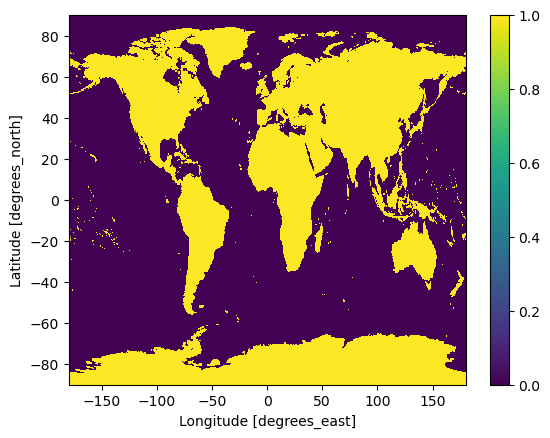

In [56]:
mask_xr.plot()

In [61]:
mask_xr = make_mask_sublevels(shp, da_population)

In [62]:
mask_xr

<xarray.DataArray (ID: 255, lat: 360, lon: 720)>
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])
Coordinates:
  * ID       (ID) object 'ABW' 'AFG' 'AGO' 'AIA' ... 'YEM' 'ZAF' 'ZMB' 'ZWE'
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

## 5. life expectancy data

In [21]:
df_unwpp = load_unwpp_lifeexpectancy(
        filepath_lifeexpectancy = filepath_lifeexpectancy,
        start_birthyear=1950,
        end_birthyear=2025
)

In [22]:
df_life_expectancy_5 = get_life_expectancies(df_unwpp,
                         start_birthyear=1950,
                         end_birthyear=2025)

# corrected to be

In [23]:
df_life_expectancy_5

Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Wallis and Futuna Islands,Western Sahara,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,73.0935,78.4736,60.3326,71.0196,72.9259,73.986,73.5868,...,76.9994,71.5994,62.5983,68.7405,68.7827,60.0066,58.8167,63.0338,68.3711,67.5054
1951,54.9914,73.117,59.9968,73.3142,78.7848,60.4601,71.3453,73.1271,74.8442,73.7835,...,77.1543,71.7428,63.0074,69.2576,69.2194,60.2678,59.0545,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,73.5873,79.0685,60.5222,71.6498,73.3441,74.3825,73.9763,...,77.303,71.891,63.3789,69.761,69.5801,60.5338,59.2911,63.3482,68.714,67.9825
1953,55.6465,75.0774,59.7686,74.0095,79.449,60.5925,71.9511,73.5912,75.4063,74.1662,...,77.4524,72.0515,63.7587,70.2772,69.953,60.8083,59.5263,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,74.5568,79.7661,60.6646,72.3025,73.8626,75.209,74.3545,...,77.5948,72.2161,64.1316,70.8107,70.2969,61.0874,59.7591,63.7344,69.1736,68.4717
1955,56.2518,76.5891,59.5298,75.0851,80.1218,60.7478,71.4231,74.0973,75.3088,74.5424,...,77.7112,72.3857,64.497,71.2998,70.7099,61.3774,59.9861,63.9845,69.3474,68.7514
1956,56.5746,76.9806,59.4297,75.4831,80.4959,58.9827,72.9037,74.4576,75.6636,74.7311,...,77.8104,72.54,64.8439,71.8403,70.9153,61.6823,60.2073,64.2225,69.5762,69.0324
1957,56.8662,77.3068,58.1319,75.6528,80.8279,59.0979,73.1615,74.7743,75.5765,74.9164,...,77.8888,72.7043,65.182,72.186,70.556,62.0178,60.4371,63.0699,69.7255,69.3188
1958,57.1442,77.6003,62.5451,75.6224,81.0699,59.1849,73.4077,75.1173,75.7557,75.0945,...,77.964,72.8695,65.5151,72.8415,69.2959,62.361,60.6635,62.1884,69.872,69.6035


In [13]:
75.9220	-11

64.922

## 6. Test 0.5 deg and filtering countries 

In [4]:
d_countries = preprocess_all_country_data(

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    ssp=2, 
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025, 

    dir_population= dir_population,     # gridded pop data 
    startyear=1950,
    endyear=2100,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = None,

    filepath_countrymask = filepath_countrymask,    # country masks 
    preprocess=False,                               # NOTE preprocessing is already done in standard input files 
    fillcoast=False, 
    fix_smallislands=False,

    # add df_countries with all worldbank countries and check if the countries are not resolved at 0.5 grid and get rid of them 
    # drop countries that are not in all datasets

    )

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 15, Bahrain, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 29, British Virgin Islands, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 32, Burkina Faso, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 39, Central African Republic, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 61, El Salvador, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 65, Eswatini, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 68, Faroe Islands, setting them t

In [5]:
d_countries

{'info_pop': None,
 'borders': <xarray.DataArray (lat: 360, lon: 720, country: 225)>
 dask.array<getitem, shape=(360, 720, 225), dtype=float32, chunksize=(299, 604, 185), chunktype=numpy.ndarray>
 Coordinates:
   * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
   * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
   * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE',
 'population_map': <xarray.DataArray 'total-population' (time: 151, lat: 360, lon: 720)>
 dask.array<concatenate, shape=(151, 360, 720), dtype=float32, chunksize=(1, 360, 720), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
   * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
   * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
 Attributes:
     long_name:  Population_count
     units:      1,
 'birth_years': None,
 'life_expectanc

In [ ]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] # its not a gdf anymore!! 
#da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years']
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
#countries_regions, countries_mask = d_countries['mask']

In [10]:
gdf_country_borders

<xarray.DataArray (lat: 360, lon: 720, country: 225)>
dask.array<getitem, shape=(360, 720, 225), dtype=float32, chunksize=(299, 604, 185), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

### make more flex option where you dont filter based on worldbank

In [3]:
df_metadata = load_country_metadata(
    filepath_isimip_countries = os.path.join(script_dir, 'data/country-masks/isipedia-countries/countryData.json'),
    filepath_world_bank = os.path.join(script_dir, 'data/income-groups/world_bank/CLASS.xlsx'), # what year is this from? 
    keep_names='isimip',
    keep_stats=False,
)
df_metadata

,country,abbreviation,country_code,region,incomegroup
0,Afghanistan,AFG,3,South Asia,Low income
1,Albania,ALB,103,Europe & Central Asia,Upper middle income
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income
3,Andorra,AND,403,Europe & Central Asia,High income
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income
...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income
192,Yemen,YEM,23003,Middle East & North Africa,Low income
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income


In [6]:
df_metadata_filter = filter_countries_all_datasets(
                                df_metadata=df_metadata,
                                filepath_lookuptable=filepath_lookuptable,
                                worldbank_filter=True, # TODO : option that doesnt filter by worldbank but only by data availability! 
                            )

In [8]:
# lookup table 249 countries
df = pd.read_csv(filepath_lookuptable) 


df_overlap = df[
            (df[["SSP name", "WPP name"]].notna().all(axis=1)) &
            (df["Data availability"] == "Full historical + SSP")
        ].reset_index(drop=True)

# worldbank and country mask matched already 
df_metadata_filtered = df_metadata.merge(df_overlap, how='inner', left_on='abbreviation', right_on='ISO alpha-3').reset_index(drop=True)

In [9]:
df_overlap

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4,Full historical + SSP,NaN
1,Albania,Albania,Albania,AL,ALB,8,Full historical + SSP,NaN
2,Algeria,Algeria,Algeria,DZ,DZA,12,Full historical + SSP,NaN
3,Angola,Angola,Angola,AO,AGO,24,Full historical + SSP,NaN
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28,Full historical + SSP,NaN
...,...,...,...,...,...,...,...,...
196,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704,Full historical + SSP,NaN
197,Western Sahara,Western Sahara,Western Sahara,EH,ESH,732,Full historical + SSP,NaN
198,Yemen,Yemen,Yemen,YE,YEM,887,Full historical + SSP,NaN
199,Zambia,Zambia,Zambia,ZM,ZMB,894,Full historical + SSP,NaN


In [11]:
da_countrymasks = load_countrymasks_fillcoasts()

In [14]:
df = pd.read_csv(filepath_lookuptable) 
df = df.merge(pd.DataFrame(da_countrymasks.country.to_pandas().rename('iso3_mask')), how='outer', left_on='ISO alpha-3', right_on='country')

df

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744.0,No data,Europe (R10),SJM
248,NaN,United States Minor Outlying Islands,NaN,UM,UMI,581.0,No population,NaN,NaN
249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSID
250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IOSID


In [16]:
df_overlap = df[
                    (df[["SSP name", "WPP name", "iso3_mask"]].notna().all(axis=1)) &
                    (df["Data availability"] == "Full historical + SSP")
                ].reset_index(drop=True)

df_overlap

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
193,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704.0,Full historical + SSP,NaN,VNM
194,Western Sahara,Western Sahara,Western Sahara,EH,ESH,732.0,Full historical + SSP,NaN,ESH
195,Yemen,Yemen,Yemen,YE,YEM,887.0,Full historical + SSP,NaN,YEM
196,Zambia,Zambia,Zambia,ZM,ZMB,894.0,Full historical + SSP,NaN,ZMB


In [38]:

def filter_countries_all_datasets(
    filepath_lookuptable=filepath_lookuptable,
    df_metadata=None,
    da_countrymask = None,
    worldbank_filter=True, # TODO : option that doesnt filter by worldbank! / more flexible method!! 

):

    # lookup table 249 countries
    df = pd.read_csv(filepath_lookuptable) 

    if worldbank_filter:

        df_overlap = df[
                    (df[["SSP name", "WPP name"]].notna().all(axis=1)) &
                    (df["Data availability"] == "Full historical + SSP")
                ].reset_index(drop=True)

        # worldbank and country mask matched already 
        df_metadata_filtered = df_metadata.merge(df_overlap, how='inner', left_on='abbreviation', right_on='ISO alpha-3').reset_index(drop=True)

        df_metadata_filtered = df_metadata_filtered[['country', 'abbreviation', 'region', 'incomegroup', 'country_code', 'SSP name', 'WPP name'   ]]

        # results in 185 world countries  

    else: 

        df = df.merge(pd.DataFrame(da_countrymasks.country.to_pandas().rename('iso3_mask')), how='outer', left_on='ISO alpha-3', right_on='country')

        df_overlap = df[
                    (df[["SSP name", "WPP name", "iso3_mask"]].notna().all(axis=1)) &
                    (df["Data availability"] == "Full historical + SSP")
                ].reset_index(drop=True)

        df_metadata_filtered = df_metadata.merge(df_overlap, how='right', left_on='abbreviation', right_on='ISO alpha-3').reset_index(drop=True)

        df_metadata_filtered = df_metadata_filtered[['country', 'iso3_mask', 'region', 'incomegroup', 'ISO numeric', 'SSP name', 'WPP name'   ]]
        df_metadata_filtered = df_metadata_filtered.rename(columns={'iso3_mask':'abbreviation', 'ISO numeric': 'country_code' })


    return df_metadata_filtered.set_index('abbreviation')



In [40]:
df_metadata_filter = filter_countries_all_datasets(
    filepath_lookuptable=filepath_lookuptable,
    df_metadata=df_metadata,
    da_countrymask = None,
    worldbank_filter=False )

In [42]:
df_metadata_filter.index

Index(['AFG', 'ALB', 'DZA', 'AGO', 'ATG', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE',
       ...
       'VIR', 'URY', 'UZB', 'VUT', 'VEN', 'VNM', 'ESH', 'YEM', 'ZMB', 'ZWE'],
      dtype='object', name='abbreviation', length=198)

### list of countries: options

Decide what to use as df_countries to filter countries in the wrapper function! 

In [ ]:
da_countrymasks = load_countrymasks_fillcoasts(
                            filepath_countrymask,
                            )


# global to check countries 

In [ ]:
df_metadata

# in World bank and in country mask : 195 countries 

,country,abbreviation,country_code,region,incomegroup
0,Afghanistan,AFG,3,South Asia,Low income
1,Albania,ALB,103,Europe & Central Asia,Upper middle income
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income
3,Andorra,AND,403,Europe & Central Asia,High income
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income
...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income
192,Yemen,YEM,23003,Middle East & North Africa,Low income
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income


In [ ]:
df_lookuptable = pd.read_csv(filepath_lookuptable)
df_lookuptable

# in lookup table: 249 countries 

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4,Full historical + SSP,NaN
1,Albania,Albania,Albania,AL,ALB,8,Full historical + SSP,NaN
2,Algeria,Algeria,Algeria,DZ,DZA,12,Full historical + SSP,NaN
3,Angola,Angola,Angola,AO,AGO,24,Full historical + SSP,NaN
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28,Full historical + SSP,NaN
...,...,...,...,...,...,...,...,...
244,NaN,Norfolk Island,NaN,NF,NFK,574,No data,Rest of Asia (R10)
245,NaN,Pitcairn,NaN,PN,PCN,612,No data,Rest of Asia (R10)
246,NaN,South Georgia and the South Sandwich Islands,NaN,GS,SGS,239,No population,NaN
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744,No data,Europe (R10)


In [ ]:
# The countries that overlap among all three data sources (UNWPP, WCDE/SSP, countrymasks) and have cohort size projections : 198 countries 

df = df_lookuptable.merge(pd.DataFrame(da_countrymasks.country.to_pandas().rename('iso3_mask')), how='outer', left_on='ISO alpha-3', right_on='country')

df_overlap = df[
    (df[["SSP name", "WPP name", 'iso3_mask']].notna().all(axis=1)) &
    (df["Data availability"] == "Full historical + SSP")
].reset_index(drop=True)

df_overlap

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
193,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704.0,Full historical + SSP,NaN,VNM
194,Western Sahara,Western Sahara,Western Sahara,EH,ESH,732.0,Full historical + SSP,NaN,ESH
195,Yemen,Yemen,Yemen,YE,YEM,887.0,Full historical + SSP,NaN,YEM
196,Zambia,Zambia,Zambia,ZM,ZMB,894.0,Full historical + SSP,NaN,ZMB


In [ ]:
# The countries that overlap among all three data sources (UNWPP, WCDE/SSP, countrymasks) and have cohort size projections AND are in WB : 185 countries 

df_all_datasources = df_metadata.merge(df_overlap, how='inner', left_on='abbreviation', right_on='ISO alpha-3').reset_index(drop=True)
df_all_datasources

# 185 countries have all data and are also in worldbank


,country,abbreviation,country_code,region,incomegroup,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,iso3_mask
0,Afghanistan,AFG,3,South Asia,Low income,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,ALB,103,Europe & Central Asia,Upper middle income,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,AGO,503,Sub-Saharan Africa,Lower middle income,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,ATG,703,Latin America & Caribbean,High income,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN,Venezuela,Venezuela (Bolivarian Republic of),Venezuela (Bolivarian Republic of),VE,VEN,862.0,Full historical + SSP,NaN,VEN
181,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income,Viet Nam,Viet Nam,Viet Nam,VN,VNM,704.0,Full historical + SSP,NaN,VNM
182,Yemen,YEM,23003,Middle East & North Africa,Low income,Yemen,Yemen,Yemen,YE,YEM,887.0,Full historical + SSP,NaN,YEM
183,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income,Zambia,Zambia,Zambia,ZM,ZMB,894.0,Full historical + SSP,NaN,ZMB


In [ ]:
df_metadata =  load_country_metadata(
                        filepath_isimip_countries = os.path.join(script_dir, 'data/country-masks/isipedia-countries/countryData.json'),
                        filepath_world_bank = os.path.join(script_dir, 'data/income-groups/world_bank/CLASS.xlsx'), # what year is this from? 
                        keep_names='isimip',
                        keep_stats=False,)

df_metadata_filter = filter_countries_all_datasets(
                        df_metadata=df_metadata,
                        filepath_lookuptable=filepath_lookuptable,
                        worldbank_filter=True, # TODO : option that doesnt filter by worldbank but only by data availability! 
                    )

In [ ]:
df_metadata_filter

,abbreviation,region,incomegroup,country_code,SSP name,WPP name
country,,,,,,
Afghanistan,AFG,South Asia,Low income,3,Afghanistan,Afghanistan
Albania,ALB,Europe & Central Asia,Upper middle income,103,Albania,Albania
Algeria,DZA,Middle East & North Africa,Upper middle income,203,Algeria,Algeria
Angola,AGO,Sub-Saharan Africa,Lower middle income,503,Angola,Angola
Antigua and Barbuda,ATG,Latin America & Caribbean,High income,703,Antigua and Barbuda,Antigua and Barbuda
...,...,...,...,...,...,...
Venezuela (Bolivarian Republic of),VEN,Latin America & Caribbean,NaN,22503,Venezuela,Venezuela (Bolivarian Republic of)
Viet Nam,VNM,East Asia & Pacific,Lower middle income,22603,Viet Nam,Viet Nam
Yemen,YEM,Middle East & North Africa,Low income,23003,Yemen,Yemen


#### filtering country fxn

In [19]:
flags

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024'}

In [13]:
df_metadata = load_country_metadata(
    filepath_isimip_countries = os.path.join(script_dir, 'data/country-masks/isipedia-countries/countryData.json'),
    filepath_world_bank = os.path.join(script_dir, 'data/income-groups/world_bank/CLASS.xlsx'), # what year is this from? 
    keep_names='isimip',
    keep_stats=False,
)

In [15]:
da_countrymasks = load_countrymasks_fillcoasts(
                            filepath_countrymask,
                            preprocess=False, # True if you want to preprocess
                            fillcoast=False, # fill coastal pixels to not lose coastal pops (done in preprocessed files)
                            fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
                            )

In [16]:
worldbank_filter=True 
data_source_cohortsizes='UNWPP2024'


In [17]:
filepath_lookuptable = data_dir+'/country-masks/lookup_table_dem4cli_v2.csv'

In [20]:
df_metadata_filtered = filter_countries_all_datasets(filepath_lookuptable,
                    df_metadata=df_metadata,                               # worldbank and country mask matched already 
    da_countrymasks = da_countrymasks,
    worldbank_filter=True, 
    data_source_cohortsizes='UNWPP2024')

In [21]:
df_metadata_filtered

,country,region,incomegroup,country_code,SSP name,WPP name
abbreviation,,,,,,
AFG,Afghanistan,South Asia,Low income,3,Afghanistan,Afghanistan
ALB,Albania,Europe & Central Asia,Upper middle income,103,Albania,Albania
DZA,Algeria,Middle East & North Africa,Upper middle income,203,Algeria,Algeria
AND,Andorra,Europe & Central Asia,High income,403,Andorra,Andorra
AGO,Angola,Sub-Saharan Africa,Lower middle income,503,Angola,Angola
...,...,...,...,...,...,...
VEN,Venezuela (Bolivarian Republic of),Latin America & Caribbean,NaN,22503,Venezuela,Venezuela (Bolivarian Republic of)
VNM,Viet Nam,East Asia & Pacific,Lower middle income,22603,Viet Nam,Viet Nam
YEM,Yemen,Middle East & North Africa,Low income,23003,Yemen,Yemen


In [18]:
df = pd.read_csv(filepath_lookuptable)
    
df = df.merge(pd.DataFrame(da_countrymasks.country.to_pandas().rename('iso3_mask')), how='outer', left_on='ISO alpha-3', right_on='country')

if data_source_cohortsizes == 'WCDE':
    df_overlap = df[
                    (df[["SSP name", "WPP name", "iso3_mask"]].notna().all(axis=1)) &
                    (df["Data availability"] == "Full historical + SSP")
                ].reset_index(drop=True)
elif data_source_cohortsizes == 'UNWPP2024':
    df_overlap = df[
                    (df[["SSP name", "WPP name", "iso3_mask"]].notna().all(axis=1)) # availability included in WPP name, the same as life expectancy data
                ].reset_index(drop=True)

if worldbank_filter:

    # only include countries that are also in WB categorization (and have all demographic data): results in 185 world countries 
    
    df_metadata_filtered = df_metadata.merge(df_overlap, how='inner', left_on='abbreviation', right_on='ISO alpha-3').reset_index(drop=True)

    df_metadata_filtered = df_metadata_filtered[['country', 'abbreviation', 'region', 'incomegroup', 'country_code', 'SSP name', 'WPP name'   ]]

else: 

    # include all countries that have all demographic data: results in 198 world countries

    df_metadata_filtered = df_metadata.merge(df_overlap, how='right', left_on='abbreviation', right_on='ISO alpha-3').reset_index(drop=True)

    df_metadata_filtered = df_metadata_filtered[['country', 'iso3_mask', 'region', 'incomegroup', 'ISO numeric', 'SSP name', 'WPP name'  ]]
    df_metadata_filtered = df_metadata_filtered.rename(columns={'iso3_mask':'abbreviation', 'ISO numeric': 'country_code' })

In [12]:
da_countrymasks

(None,)